In [1]:
#from neural_priors.utils.data import get_all_behavioral_data, get_all_subject_ids
import pingouin as pg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os, pickle
from scipy import stats, odr, optimize
import statsmodels.api as sm
import itertools

In [2]:
plt.rcParams['legend.frameon'] = False
np.set_printoptions(linewidth=140)
pd.set_option('display.width', 170) # 80
pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 70)

In [3]:
#import apc_utils as apc

In [4]:
# from functools import cache
# from cachetools import cached

In [5]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
#COLORS_COND = {NARROW:'C0', WIDE:'C1'}
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#55BB55'; FOURTH_COLOR = 'C4' # THIRD_COLOR = '#009E73'; 
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [6]:
"#00BB00"

'#00BB00'

In [7]:
def quick_ols(y, x, include_intercept=True):
    if not include_intercept:
        model = sm.OLS(y, x)
    else:
        model = sm.OLS(y, sm.add_constant(x))
    return model.fit()

In [8]:
def paired_strip_plot(ax, x1, x2, y1, y2, jitter=0.05,
                      marker='o', markersize=8, col1='C0', col2='C1',
                      color_line='grey', alpha=0.4, line_width=0.5,
                      color_incr_line=None, color_decr_line=None
                      ):
    """
    Creates a paired strip plot on the given axis.
    
    Parameters:
      ax : matplotlib.axes.Axes
          The axis to plot on.
      x1, x2 : float
          The x-axis positions for the two groups.
      y1, y2 : array-like
          The y-values for the two groups. They should have the same length.
      jitter : float, optional
          The standard deviation of the jitter to add to the x positions (default 0.05).
      marker : str, optional
          The marker style for the points (default 'o').
      markersize : int, optional
          The marker size (default 8).
      col1 : str, optional
          The color for the points in group 1 (default 'C0').
      col2 : str, optional
          The color for the points in group 2 (default 'C1').
      color_line : str, optional
          The color for the connecting lines (default 'grey').
      alpha : float, optional
          The transparency for points and lines (default 0.4).
      line_width : float, optional
          The width of the connecting lines (default 0.5).
    """
    
    color_incr_line = color_incr_line or color_line
    color_decr_line = color_decr_line or color_line

    # Create jittered x positions for each group
    xs1 = np.full(len(y1), x1) + np.random.normal(0, jitter, size=len(y1))
    xs2 = np.full(len(y2), x2) + np.random.normal(0, jitter, size=len(y2))

    # Plot the points for both groups with separate colors
    ax.plot(xs1, y1, linestyle='None', marker=marker, markersize=markersize,
            color=col1, alpha=alpha)
    ax.plot(xs2, y2, linestyle='None', marker=marker, markersize=markersize,
            color=col2, alpha=alpha)

    # Connect each paired point with a line
    for xi1, xi2, yi1, yi2 in zip(xs1, xs2, y1, y2):
        c = color_incr_line if yi2 > yi1 else color_decr_line if yi2 < yi1 else color_line
        ax.plot([xi1, xi2], [yi1, yi2], color=c,
                linewidth=line_width, alpha=alpha)

In [9]:
def index_filter(df, **kwargs):
    """
    Filter a DataFrame based on index level value(s) and drop levels uniquely determined
    by a single-value filter.

    For a MultiIndex, only those levels filtered by a single element (not list-like)
    that then have only one unique value in the result are dropped.
    For a simple index, if the filtering criterion is a single element and the index
    becomes constant, the index is reset (dropped).

    Parameters:
        df (pd.DataFrame): The DataFrame to filter.
        **kwargs: Each keyword corresponds to an index level name and its filter condition.
                  The condition may be a single value or a list/tuple/set of acceptable values.

    Returns:
        pd.DataFrame: The filtered DataFrame.
    """
    # No filters provided; return the original DataFrame.
    if not kwargs:
        return df

    idx = df.index

    # MultiIndex handling.
    if isinstance(idx, pd.MultiIndex):
        mask = np.ones(len(df), dtype=bool)
        # Build the mask for each provided index level.
        for level, value in kwargs.items():
            if level not in idx.names:
                raise KeyError(f"Index level '{level}' not found in MultiIndex {idx.names}.")
            if not isinstance(value, str) and hasattr(value, '__iter__'): #isinstance(value, (list, tuple, set)):
                mask &= idx.get_level_values(level).isin(value)
            else:
                mask &= (idx.get_level_values(level) == value)
        filtered_df = df[mask]

        # Only drop levels that were filtered with a single value and are constant.
        to_drop = [level for level, value in kwargs.items() 
                   if not isinstance(value, (list, tuple, set)) 
                   and filtered_df.index.get_level_values(level).nunique() == 1]
        if to_drop:
            filtered_df = filtered_df.droplevel(to_drop)
        return filtered_df

    # Simple index handling.
    else:
        if len(kwargs) > 1:
            raise ValueError("A simple index DataFrame accepts only one filtering criterion.")
        key, value = next(iter(kwargs.items()))
        # If the simple index has a name, it must match the key.
        if idx.name is not None and idx.name != key:
            raise KeyError(f"Simple index name '{idx.name}' does not match filter key '{key}'.")
        # Apply the filtering.
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            mask = idx.isin(value)
        else:
            mask = (idx == value)
        filtered_df = df[mask]

        # Drop the index (by resetting it) only if the filter was a single value and the index is constant.
        if not isinstance(value, (list, tuple, set)) and filtered_df.index.nunique() == 1:
            filtered_df = filtered_df.reset_index(drop=True)
        return filtered_df

# Models

In [10]:
#bids_folder = Path('/data/ds-neuralpriors')
pars_ground_truth = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-08-06.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-08-06.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars = pd.concat([pars_ground_truth, pars_estimates], keys=['ground_truth', 'estimates'], names=['type'], axis=0)

# rename index level subject_id to subject
pars.index.set_names('subject', level='subject_id', inplace=True)

pars.index.unique(level='smoothed')

pars

parameter                                             mu                   sd           delta_wide      amplitude            baseline                  r2      cvr2
range                                             narrow       wide    narrow      wide     narrow wide    narrow      wide    narrow      wide       nan       nan
type         subject model_label smoothed                                                                                                                          
ground_truth 1       0           True     0    10.698851  10.698851  0.128387  0.128387        1.0  1.0  0.287954  0.287954 -0.117511 -0.117511  0.007678 -0.018960
                                          1    12.097051  12.097051  0.047358  0.047358        1.0  1.0  0.396764  0.396764 -0.512096 -0.512096  0.007553 -0.019339
                                          2    13.019329  13.019329  0.156827  0.156827        1.0  1.0  0.160411  0.160411 -0.514299 -0.514299  0.005133 -0.026036
                                          3    15.027272  15.027272  0.071559  0.071559        1.0  1.0  0.305217  0.305217 -0.310229 -0.310229  0.014921 -0.021961
                                          4    11.410503  11.410503  0.092538  0.092538        1.0  1.0  0.359884  0.359884 -0.109330 -0.109330  0.007671 -0.015200
...                                                  ...        ...       ...       ...        ...  ...       ...       ...       ...       ...       ...       ...
estimates    41      33          True     689  13.448326  16.896652  0.565678  0.728476        2.0  2.0  0.464496  0.518247 -0.045288 -0.045288  0.029204  0.011950
                                          690   9.908031   9.908031  0.152317  0.196154        2.0  2.0  0.108694  0.121272  0.277198  0.277198  0.006743 -0.015981
                                          691  13.634396  17.268791  0.521635  0.671758        2.0  2.0  0.387509  0.432351 -0.075840 -0.075840  0.022160  0.002292
                                          692   8.510156   8.510156  0.498837  0.642400        2.0  2.0  0.241137  0.269041 -0.121465 -0.121465  0.014179 -0.008607
                                          693  13.615266  17.230532  0.599750  0.772355        2.0  2.0  0.331217  0.369545 -0.205013 -0.205013  0.007632 -0.006012

[1038122 rows x 12 columns]

In [11]:
pars_groundtruth_0806 = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-08-06.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_groundtruth_0513 = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-05-13.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates_0806 = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-08-06.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates_0513 = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-05-13.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
print('% cvR2>0')
print(f'Ground Truth:\tAug 6: {(pars_groundtruth_0806.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, May 13: {(pars_groundtruth_0513.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}')
print(f'Estimates:\tAug 6: {(pars_estimates_0806.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, May 13: {(pars_estimates_0513.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}')

% cvR2>0
Ground Truth:	Aug 6: 0.2877, May 13: 0.2884
Estimates:	Aug 6: 0.3189, May 13: 0.3182


In [12]:
ratiosd_groundtruth_0806 = ( pars_groundtruth_0806.loc[:,15,True].sd.wide / pars_groundtruth_0806.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_groundtruth_0513 = ( pars_groundtruth_0513.loc[:,15,True].sd.wide / pars_groundtruth_0513.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_estimates_0806 = ( pars_estimates_0806.loc[:,15,True].sd.wide / pars_estimates_0806.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_estimates_0513 = ( pars_estimates_0513.loc[:,15,True].sd.wide / pars_estimates_0513.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
print('MEAN ratio_sd')
print(f'Ground Truth SD Ratios:\tAug 6: {ratiosd_groundtruth_0806.mean():.4f}, May 13: {ratiosd_groundtruth_0513.mean():.4f}')
print(f'Estimates SD Ratios:\tAug 6: {ratiosd_estimates_0806.mean():.4f}, May 13: {ratiosd_estimates_0513.mean():.4f}')
print('\nMEDIAN ratio_sd')
print(f'Ground Truth SD Ratios:\tAug 6: {ratiosd_groundtruth_0806.median():.4f}, May 13: {ratiosd_groundtruth_0513.median():.4f}')
print(f'Estimates SD Ratios:\tAug 6: {ratiosd_estimates_0806.median():.4f}, May 13: {ratiosd_estimates_0513.median():.4f}')

MEAN ratio_sd
Ground Truth SD Ratios:	Aug 6: 1.2878, May 13: 1.2651
Estimates SD Ratios:	Aug 6: 1.3048, May 13: 1.2715

MEDIAN ratio_sd
Ground Truth SD Ratios:	Aug 6: 1.3093, May 13: 1.2877
Estimates SD Ratios:	Aug 6: 1.3212, May 13: 1.3026


In [13]:
ytype = 'ground_truth'
da = index_filter(pars, smoothed=True, type=ytype)
da['cvr2_pos'] = da.cvr2 > 0
rez = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
rez = rez.unstack()
rez

model_label,0,3,4,5,12,14,15,18,25,26,27,28,29,30,31,32,33
subject,,,,,,,,,,,,,,,,,
1,0.118029,0.093385,0.140078,0.110246,0.133593,0.116732,0.118029,0.103761,0.160830,0.114137,0.146563,0.125811,0.141375,0.111543,0.155642,0.143969,0.143969
2,0.127907,0.106977,0.125581,0.108140,0.086047,0.086047,0.118605,0.094186,0.105814,0.109302,0.102326,0.117442,0.096512,0.117442,0.115116,0.105814,0.117442
3,0.070028,0.040616,0.065826,0.043417,0.054622,0.032213,0.040616,0.047619,0.042017,0.046218,0.039216,0.040616,0.030812,0.032213,0.047619,0.026611,0.040616
4,0.298065,0.209032,0.308387,0.280000,0.249032,0.243871,0.282581,0.274839,0.313548,0.272258,0.291613,0.278710,0.294194,0.243871,0.312258,0.291613,0.304516
5,0.165436,0.094535,0.175775,0.051699,0.135894,0.124077,0.181684,0.118168,0.177253,0.158050,0.152142,0.131462,0.152142,0.132939,0.192024,0.172821,0.172821
6,0.196273,0.191304,0.257143,0.214907,0.285714,0.318012,0.350311,0.277019,0.346584,0.180124,0.259627,0.218634,0.257143,0.217391,0.334161,0.311801,0.320497
7,0.445067,0.419283,0.449552,0.447309,0.452915,0.426009,0.477578,0.461883,0.471973,0.437220,0.440583,0.437220,0.437220,0.410314,0.465247,0.450673,0.469731
8,0.366352,0.279874,0.360063,0.345912,0.336478,0.319182,0.369497,0.372642,0.397799,0.316038,0.339623,0.320755,0.333333,0.290881,0.393082,0.360063,0.391509
9,0.442700,0.365777,0.458399,0.419152,0.463108,0.412873,0.463108,0.447410,0.466248,0.431711,0.428571,0.427002,0.431711,0.390895,0.470958,0.427002,0.463108


In [14]:
rez.columns

Index([0, 3, 4, 5, 12, 14, 15, 18, 25, 26, 27, 28, 29, 30, 31, 32, 33], dtype='int64', name='model_label')

In [15]:
da = index_filter(pars, smoothed=True, type='estimates')
da['cvr2_pos'] = da.cvr2 > 0
rez_est = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
rez_est = rez_est.unstack()
#rez_est

In [16]:
rez_est

model_label,0,3,4,5,12,14,15,18,25,26,27,28,29,30,31,32,33
subject,,,,,,,,,,,,,,,,,
1,0.151751,0.103761,0.136187,0.112840,0.121920,0.125811,0.137484,0.132296,0.150454,1.000000,0.138781,0.125811,0.137484,0.137484,0.150454,0.143969,0.159533
2,0.116279,0.140698,0.186047,0.182558,0.125581,0.155814,0.166279,0.154651,0.167442,0.173256,0.177907,0.172093,0.165116,0.141860,0.172093,0.162791,0.172093
3,0.085434,0.049020,0.121849,0.106443,0.064426,0.061625,0.107843,0.091036,0.106443,0.096639,0.086835,0.091036,0.084034,0.067227,0.119048,0.082633,0.109244
4,0.219355,0.214194,0.252903,0.240000,0.285161,0.298065,0.345806,0.318710,0.360000,0.289032,0.330323,0.300645,0.325161,0.276129,0.332903,0.292903,0.321290
5,0.168390,0.088626,0.158050,0.116691,0.146233,0.159527,0.192024,0.146233,0.192024,0.166913,0.192024,0.162482,0.190547,0.165436,0.197932,0.175775,0.174298
6,0.180124,0.142857,0.176398,0.165217,0.175155,0.207453,0.275776,0.237267,0.263354,0.090683,0.202484,0.088199,0.198758,0.116770,0.244720,0.226087,0.238509
7,0.426009,0.378924,0.412556,0.414798,0.412556,0.395740,0.461883,0.449552,0.466368,0.423767,0.426009,0.427130,0.417040,0.364350,0.461883,0.445067,0.459641
8,0.342767,0.305031,0.424528,0.413522,0.353774,0.349057,0.446541,0.408805,0.438679,0.375786,0.413522,0.400943,0.404088,0.341195,0.444969,0.426101,0.444969
9,0.483516,0.430141,0.492936,0.488226,0.494505,0.466248,0.455259,0.448980,0.477237,0.474097,0.422292,0.444270,0.427002,0.450549,0.483516,0.463108,0.458399


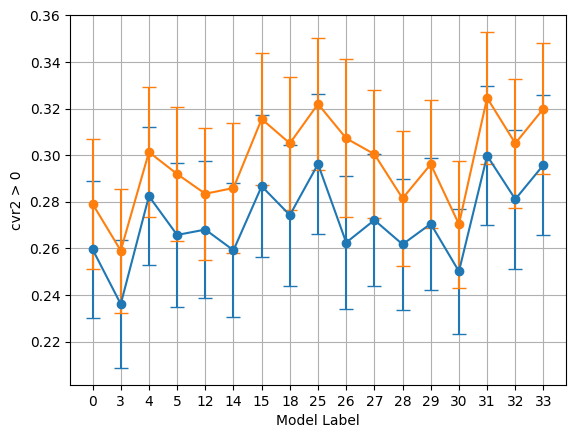

In [17]:
# plt.errorbar(x=rez.columns, y=rez.mean(), yerr=rez.sem(), fmt='-o', capsize=5)
# plt.errorbar(x=rez_est.columns, y=rez_est.mean(), yerr=rez_est.sem(), fmt='-o', capsize=5)
plt.errorbar(x=np.arange(100,100+len(rez.columns)), y=rez.mean(), yerr=rez.sem(), fmt='-o', capsize=5)
plt.errorbar(x=np.arange(100,100+len(rez.columns)), y=rez_est.mean(), yerr=rez_est.sem(), fmt='-o', capsize=5)
plt.xlabel('Model Label')
plt.ylabel('cvr2 > 0')
plt.grid()
plt.xticks(np.arange(100,100+len(rez.columns)));
plt.gca().set_xticklabels(rez.columns);

In [18]:
compare_res = []
# Iterate over the model pairs and perform paired t-tests
for (mo1, mo2) in [(4, 12), (4, 14), (4, 15), (18, 4), (25,31)]:
    ttest_result = pg.ttest(x=rez[mo1], y=rez[mo2], paired=True)
    # Append the results to the list, including the t-test result as a row
    compare_res.append({
        'Model 1': mo1,
        'Model 2': mo2,
        'Mean Model 1': rez[mo1].mean(),
        'Mean Model 2': rez[mo2].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_res = pd.DataFrame(compare_res)
compare_res

,Model 1,Model 2,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
0,4,12,0.282406,0.268072,2.749251,38,two-sided,0.009091,"[0.0, 0.02]",0.077962,4.463,0.076188
1,4,14,0.282406,0.259189,4.020968,38,two-sided,0.000265,"[0.01, 0.03]",0.127644,101.052,0.121538
2,4,15,0.282406,0.286667,-0.701418,38,two-sided,0.487316,"[-0.02, 0.01]",0.022701,0.217,0.052191
3,18,4,0.274279,0.282406,-1.264208,38,two-sided,0.213855,"[-0.02, 0.0]",0.043553,0.361,0.058094
4,25,31,0.296175,0.299754,-1.770327,38,two-sided,0.084695,"[-0.01, 0.0]",0.019081,0.713,0.051548


In [19]:
compare_res_est = []
# Iterate over the model pairs and perform paired t-tests
#for (mo1, mo2) in [(4, 12), (4, 14), (4, 15), (18, 4)]:
for (mo1, mo2) in itertools.combinations([0, 3, 4, 5, 14, 15, 18, 25, 31, 32, 33], 2):
    ttest_result = pg.ttest(x=rez_est[mo1], y=rez_est[mo2], paired=True)
    # Append the results to the list, including the t-test result as a row
    compare_res_est.append({
        'Model1': mo1,
        'Model2': mo2,
        'Mean Model 1': rez_est[mo1].mean(),
        'Mean Model 2': rez_est[mo2].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_res_est = pd.DataFrame(compare_res_est)
compare_res_est = compare_res_est.set_index(['Model1', 'Model2'])
compare_res_est

Mean Model 1  Mean Model 2          T  dof alternative         p-val           CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                     
0      3           0.279088      0.259048   2.477756   38   two-sided  1.778123e-02     [0.0, 0.04]  0.117554      2.527  0.110432
       4           0.279088      0.301325  -3.633257   38   two-sided  8.242335e-04  [-0.03, -0.01]  0.127370     36.545  0.121224
       5           0.279088      0.291914  -1.995938   38   two-sided  5.314412e-02    [-0.03, 0.0]  0.072274      1.029  0.072464
       14          0.279088      0.285912  -0.890781   38   two-sided  3.786519e-01   [-0.02, 0.01]  0.039057       0.25  0.056503
       15          0.279088      0.315511  -4.386505   38   two-sided  8.829722e-05  [-0.05, -0.02]  0.207314    274.021  0.243261
       18          0.279088      0.305074  -3.370299   38   two-sided  1.734544e-03  [-0.04, -0.01]  0.147224      18.88  0.145890
       25          0.279088      0.321951  -4.867659   38   two-sided  2.005614e-05  [-0.06, -0.03]  0.243181   1063.669  0.316044
       31          0.279088      0.324579  -5.699292   38   two-sided  1.471962e-06  [-0.06, -0.03]  0.258680  1.192e+04  0.350217
       32          0.279088      0.305058  -3.057909   38   two-sided  4.069229e-03  [-0.04, -0.01]  0.148992      8.936  0.148271
       33          0.279088      0.319992  -5.289302   38   two-sided  5.360906e-06  [-0.06, -0.03]  0.233181   3592.227  0.294803
3      4           0.259048      0.301325  -8.258465   38   two-sided  5.234141e-10  [-0.05, -0.03]  0.248617  2.104e+07  0.327867
       5           0.259048      0.291914  -5.836502   38   two-sided  9.542291e-07  [-0.04, -0.02]  0.189978  1.785e+04  0.211787
       14          0.259048      0.285912  -5.647908   38   two-sided  1.731278e-06  [-0.04, -0.02]  0.157854  1.025e+04  0.160659
       15          0.259048      0.315511  -7.761179   38   two-sided  2.352568e-09  [-0.07, -0.04]  0.329843  5.059e+06  0.519065
       18          0.259048      0.305074  -8.871793   38   two-sided  8.522324e-11  [-0.06, -0.04]  0.267562  1.183e+08  0.370397
       25          0.259048      0.321951  -8.613689   38   two-sided  1.819421e-10  [-0.08, -0.05]  0.366214  5.746e+07  0.606043
       31          0.259048      0.324579 -10.325412   38   two-sided  1.391496e-12  [-0.08, -0.05]  0.382431   6.02e+09  0.643437
       32          0.259048      0.305058  -8.922875   38   two-sided  7.341546e-11  [-0.06, -0.04]  0.271033  1.363e+08  0.378390
       33          0.259048      0.319992 -10.277476   38   two-sided  1.586814e-12  [-0.07, -0.05]  0.356603  5.308e+09  0.583387
4      5           0.301325      0.291914   2.592253   38   two-sided  1.345899e-02     [0.0, 0.02]  0.053155      3.196  0.062084
       14          0.301325      0.285912   3.452399   38   two-sided  1.378281e-03    [0.01, 0.02]  0.088430     23.138  0.083816
       15          0.301325      0.315511  -2.653206   38   two-sided  1.157367e-02   [-0.03, -0.0]  0.080935      3.633  0.078252
       18          0.301325      0.305074  -0.801768   38   two-sided  4.276727e-01   [-0.01, 0.01]  0.021289      0.233  0.051927
       25          0.301325      0.321951  -3.456318   38   two-sided  1.363162e-03  [-0.03, -0.01]  0.117294     23.365  0.110160
       31          0.301325      0.324579  -5.058881   38   two-sided  1.104442e-05  [-0.03, -0.01]  0.132543   1842.339  0.127284
       32          0.301325      0.305058  -0.734171   38   two-sided  4.673506e-01   [-0.01, 0.01]  0.021464      0.222  0.051959
       33          0.301325      0.319992  -4.043654   38   two-sided  2.480289e-04  [-0.03, -0.01]  0.106666    107.399  0.099543
5      14          0.291914      0.285912   1.029888   38   two-sided  3.095736e-01   [-0.01, 0.02]  0.033876      0.282  0.054888
       15          0.291914      0.315511  -3.281312   38   two-sided  2.219578e-03  

In [20]:
compare_res_est.reset_index()[(compare_res_est.reset_index().Model1 == 18) | (compare_res_est.reset_index().Model2 == 18)].set_index(['Model1', 'Model2'])

Mean Model 1  Mean Model 2         T  dof alternative         p-val           CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                    
0      18          0.279088      0.305074 -3.370299   38   two-sided  1.734544e-03  [-0.04, -0.01]  0.147224      18.88  0.145890
3      18          0.259048      0.305074 -8.871793   38   two-sided  8.522324e-11  [-0.06, -0.04]  0.267562  1.183e+08  0.370397
4      18          0.301325      0.305074 -0.801768   38   two-sided  4.276727e-01   [-0.01, 0.01]  0.021289      0.233  0.051927
5      18          0.291914      0.305074 -2.419512   38   two-sided  2.043490e-02   [-0.02, -0.0]  0.073543       2.25  0.073269
14     18          0.285912      0.305074 -5.557298   38   two-sided  2.304495e-06  [-0.03, -0.01]  0.108738   7858.129  0.101529
15     18          0.315511      0.305074  2.940512   38   two-sided  5.551349e-03     [0.0, 0.02]  0.058903      6.824  0.064861
18     25          0.305074      0.321951 -4.020461   38   two-sided  2.657435e-04  [-0.03, -0.01]  0.094945    100.915  0.089077
       31          0.305074      0.324579 -6.328995   38   two-sided  2.015734e-07  [-0.03, -0.01]  0.109976  7.632e+04  0.102735
       32          0.305074      0.305058  0.005243   38   two-sided  9.958441e-01   [-0.01, 0.01]  0.000095      0.173  0.050000
       33          0.305074      0.319992 -4.504338   38   two-sided  6.160713e-05  [-0.02, -0.01]  0.084320     380.45  0.080701

In [21]:
pg.ttest(x=rez_est[4], y=rez_est[5], paired=True, alternative='greater')

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.592253,38,greater,0.006729,"[0.0, inf]",0.053155,6.392,0.093623


In [22]:
def star_line(ax, x1, x2, y, pval, star_size=10, star_offset=0, star_color='black', line_color='black', line_width=1, vertical_lines_length=0.05, ):
    """
    Draws a star and a line between two x positions at a specified y position on the given axis.
    """
    # Determine the number of stars based on the p-value
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    
    # Draw the stars at the specified position
    ax.text((x1 + x2) / 2, y + star_offset, stars, fontsize=star_size, color=star_color, ha='center', va='bottom')

    # Draw a line between the two x positions at the specified y position
    ax.plot([x1, x2], [y, y], color=line_color, linewidth=line_width)

    if vertical_lines_length > 0:
        # Draw vertical lines at the ends of the horizontal line
        ax.plot([x1, x1], [y - vertical_lines_length, y], color=line_color, linewidth=line_width)
        ax.plot([x2, x2], [y - vertical_lines_length, y], color=line_color, linewidth=line_width)

In [23]:
from matplotlib.transforms import ScaledTranslation

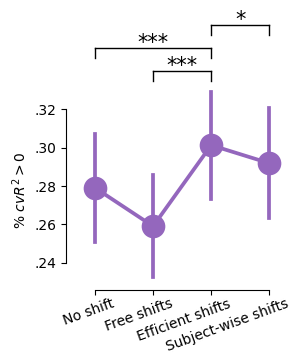

In [24]:
fig, ax = plt.subplots(figsize=(3, 3.6))
modelz = dict( [(0, 'No shift'), (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Subject-wise shifts')] )
these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color=FOURTH_COLOR, markersize=15, ax=ax)
ax.set_xlabel(None)
#### x ticks labels positions
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12/72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.24, .26, .28, .3, .32])
ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
#ax.set_ylim(.23, .33)
ax.spines.left.set_bounds((.24, .32))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.0025
star_line(ax, 0, 2, .352, compare_res_est.loc[(0,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .340, compare_res_est.loc[(3,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 3, 2, .364, compare_res_est.loc[(4,5)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)

In [25]:
these_rez

model_label,No shift,Free shifts,Efficient shifts,Subject-wise shifts
subject,,,,
1,0.151751,0.103761,0.136187,0.112840
2,0.116279,0.140698,0.186047,0.182558
3,0.085434,0.049020,0.121849,0.106443
4,0.219355,0.214194,0.252903,0.240000
5,0.168390,0.088626,0.158050,0.116691
6,0.180124,0.142857,0.176398,0.165217
7,0.426009,0.378924,0.412556,0.414798
8,0.342767,0.305031,0.424528,0.413522
9,0.483516,0.430141,0.492936,0.488226


# Model 3 - Free mus

In [26]:
df3 = index_filter(pars, type='estimates', smoothed=True, model_label=3, ) 
df3 = df3[ df3[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
df3.index.rename(['subject', 'voxel'], inplace=True)
df3[('mu', 'delta_wn')] = df3[('mu', 'wide')] - df3[('mu', 'narrow')]

In [27]:
df3

parameter             mu                   sd           delta_wide           amplitude            baseline                  r2      cvr2        mu
range             narrow       wide    narrow      wide     narrow      wide    narrow      wide    narrow      wide       nan       nan  delta_wn
subject voxel                                                                                                                                     
1       10     11.682623  16.416372  0.620960  0.620960   3.335587  3.335587  0.894001  0.894001 -1.021131 -1.021131  0.022224  0.002166  4.733749
        19     11.699798  12.155348  0.298874  0.298874   0.432271  0.432271  0.366680  0.366680 -0.324603 -0.324603  0.027029  0.000930  0.455550
        20     12.507381  13.631636  0.314411  0.314411  -0.807929 -0.807929  0.500685  0.500685 -0.589729 -0.589729  0.029938  0.007833  1.124256
        21     11.741282  12.658101  0.323126  0.323126  -0.100547 -0.100547  0.339480  0.339480 -0.182902 -0.182902  0.034864  0.015999  0.916819
        22     12.506862  13.648597  0.303899  0.303899  -1.235623 -1.235623  0.433540  0.433540 -0.416746 -0.416746  0.041086  0.028506  1.141735
...                  ...        ...       ...       ...        ...       ...       ...       ...       ...       ...       ...       ...       ...
41      683    12.316301  17.959295  0.596014  0.596014   3.070401  3.070401  0.324755  0.324755 -0.010704 -0.010704  0.036365  0.006856  5.642994
        684    15.974920  20.638970  0.141011  0.141011   1.843548  1.843548  0.254338  0.254338  0.155235  0.155235  0.041298  0.017604  4.664050
        686    11.896716  11.782497  0.284142  0.284142   0.858693  0.858693  0.308839  0.308839 -0.231846 -0.231846  0.027281  0.003801 -0.114219
        687    12.096848  11.868406  0.275633  0.275633   0.705122  0.705122  0.322327  0.322327 -0.062738 -0.062738  0.031246  0.007987 -0.228442
        689    10.982932  16.882748  1.201802  1.201802   3.649241  3.649241  1.045254  1.045254 -0.603918 -0.603918  0.027689  0.003679  5.899816

[8008 rows x 13 columns]

In [28]:
print( pg.corr( df3.mu.narrow, df3.mu.wide ) )
subject_corrs = df3.groupby(level='subject').apply(lambda g: pg.corr(g.mu.narrow, g.mu.wide))
subject_corrs.describe()

            n         r         CI95%  p-val BF10  power
pearson  8008  0.668998  [0.66, 0.68]    0.0  inf    1.0


,n,r,p-val,power
count,39.000000,39.000000,3.900000e+01,39.000000
mean,205.333333,0.739087,1.903197e-06,0.999417
std,141.325554,0.172403,1.049524e-05,0.002686
min,35.000000,0.238809,3.889708e-167,0.983675
25%,86.500000,0.629336,4.950078e-66,1.000000
50%,157.000000,0.762910,1.455344e-28,1.000000
75%,294.500000,0.881423,1.238829e-12,1.000000
max,517.000000,0.961644,6.536301e-05,1.000000


37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.983, p = 6.16e-11, dof = 38


/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_95232/263453751.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")


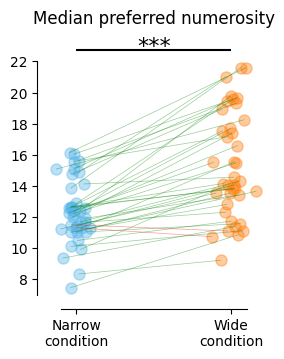

In [29]:
# Compute per-subject medians for 'mu' in 'wide' and 'narrow'
#ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )

fig, ax = plt.subplots(figsize=(3, 3.6))
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median preferred numerosity")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(6.1,23.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')

ax.spines.left.set_bounds((7, 22))
ax.spines.bottom.set_bounds((.9, 2.1))

#fig.savefig('figures/delta_median_mu.pdf', bbox_inches='tight')

In [30]:
paired_test['p-val']

T-test    6.163888e-11
Name: p-val, dtype: float64

In [31]:
df3.index.get_level_values('subject').unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$


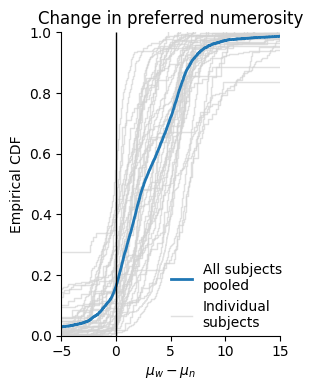

In [32]:
fig, ax = plt.subplots(figsize=(3, 4))
all_data = []
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
subjects = df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = df3.xs(subject, level='subject')[('mu', 'delta_wn')]
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x='mu_delta_wn', color='C0', linewidth=2, label='All subjects pooled')
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )

#plt.title("Empirical CDF of $\mu_{w} - \mu_{n}$")
plt.gca().set_title("Change in preferred numerosity")
plt.xlabel('$\mu_{w} - \mu_{n}$')
plt.ylabel('Empirical CDF')
plt.legend(handles=[plt.Line2D([0], [0], color='C0', lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
plt.tight_layout()
plt.xlim(-5, 15)
plt.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# fig.savefig('figures/cdf_delta_mu.pdf', bbox_inches='tight')

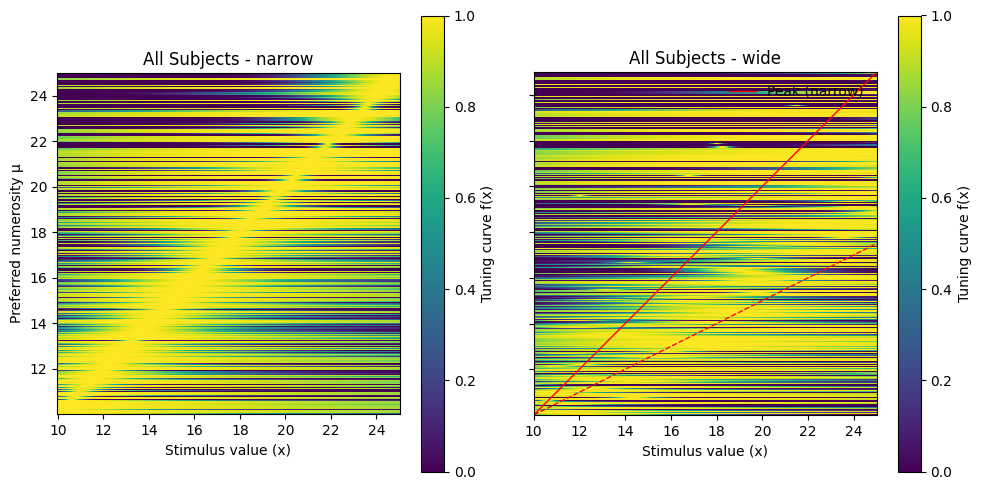

In [33]:
# Filter: only voxels with 10 <= mu (narrow) <= 25
mu_narrow_all = df3[('mu', 'narrow')]
mask = (mu_narrow_all >= 10) & (mu_narrow_all <= 25)
filtered_voxel_indices = mu_narrow_all[mask].sort_values().index          

x_vals   = np.linspace(10, 25, 200)
dx = x_vals[1] - x_vals[0]
x_edges  = np.linspace(x_vals[0]-dx/2, x_vals[-1]+dx/2, len(x_vals)+1)

# NEW  y-edges so vertical position depends only on μ, not voxel count
mu_sorted = df3.loc[filtered_voxel_indices][('mu', 'narrow')].values
y_edges   = np.concatenate(([mu_sorted[0] - (mu_sorted[1]-mu_sorted[0])/2],
                            (mu_sorted[:-1] + mu_sorted[1:]) / 2,
                            [mu_sorted[-1] + (mu_sorted[-1]-mu_sorted[-2])/2]))

conditions = ['narrow', 'wide']
fig, axes = plt.subplots(1, 2, figsize=(10, 5 ), sharey=True)

for ax in axes: 
    ax.set_aspect('equal', adjustable='box') 

peak_locs = []

for i, cond in enumerate(conditions):
    ax = axes[i]
    img = []
    for idx in filtered_voxel_indices:
        #baseline  = df3.loc[idx][('baseline',  cond)]
        #amplitude = df3.loc[idx][('amplitude', cond)]
        mu        = df3.loc[idx][('mu',       cond)]
        sd        = df3.loc[idx][('sd',       cond)]
        #fx = np.exp(-.5*((x_vals - mu) / sd) ** 2)
        fx = np.exp(-.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2)
        #fx = -.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2
        #fx = baseline + amplitude * np.exp(-.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2)
        img.append(fx)
        if i == 0:
            peak_locs.append(mu)
    img = np.array(img)

    # CHANGED ↓  imshow → pcolormesh with the pre-computed edges
    im = ax.pcolormesh(x_edges, y_edges, img, shading='auto', cmap='viridis')

    ax.set_title(f'All Subjects - {cond}')
    ax.set_xlabel('Stimulus value (x)')
    if i == 0:
        ax.set_ylabel('Preferred numerosity μ')
    fig.colorbar(im, ax=ax, label='Tuning curve f(x)')

    if i == 1:
        # CHANGED ↓  use μ values instead of row indices
        ax.plot(peak_locs, mu_sorted, 'r-',  linewidth=1, label='Peak (narrow)')
        ax.plot(10 + 2*(np.array(peak_locs) - 10), mu_sorted, 'r--', linewidth=1)
        ax.legend(loc='upper right')
        ax.set_xlim(x_vals[0], x_vals[-1])

    # # NEW  flip so small μ at top
    # ax.invert_yaxis()                                               

plt.tight_layout()
plt.show()


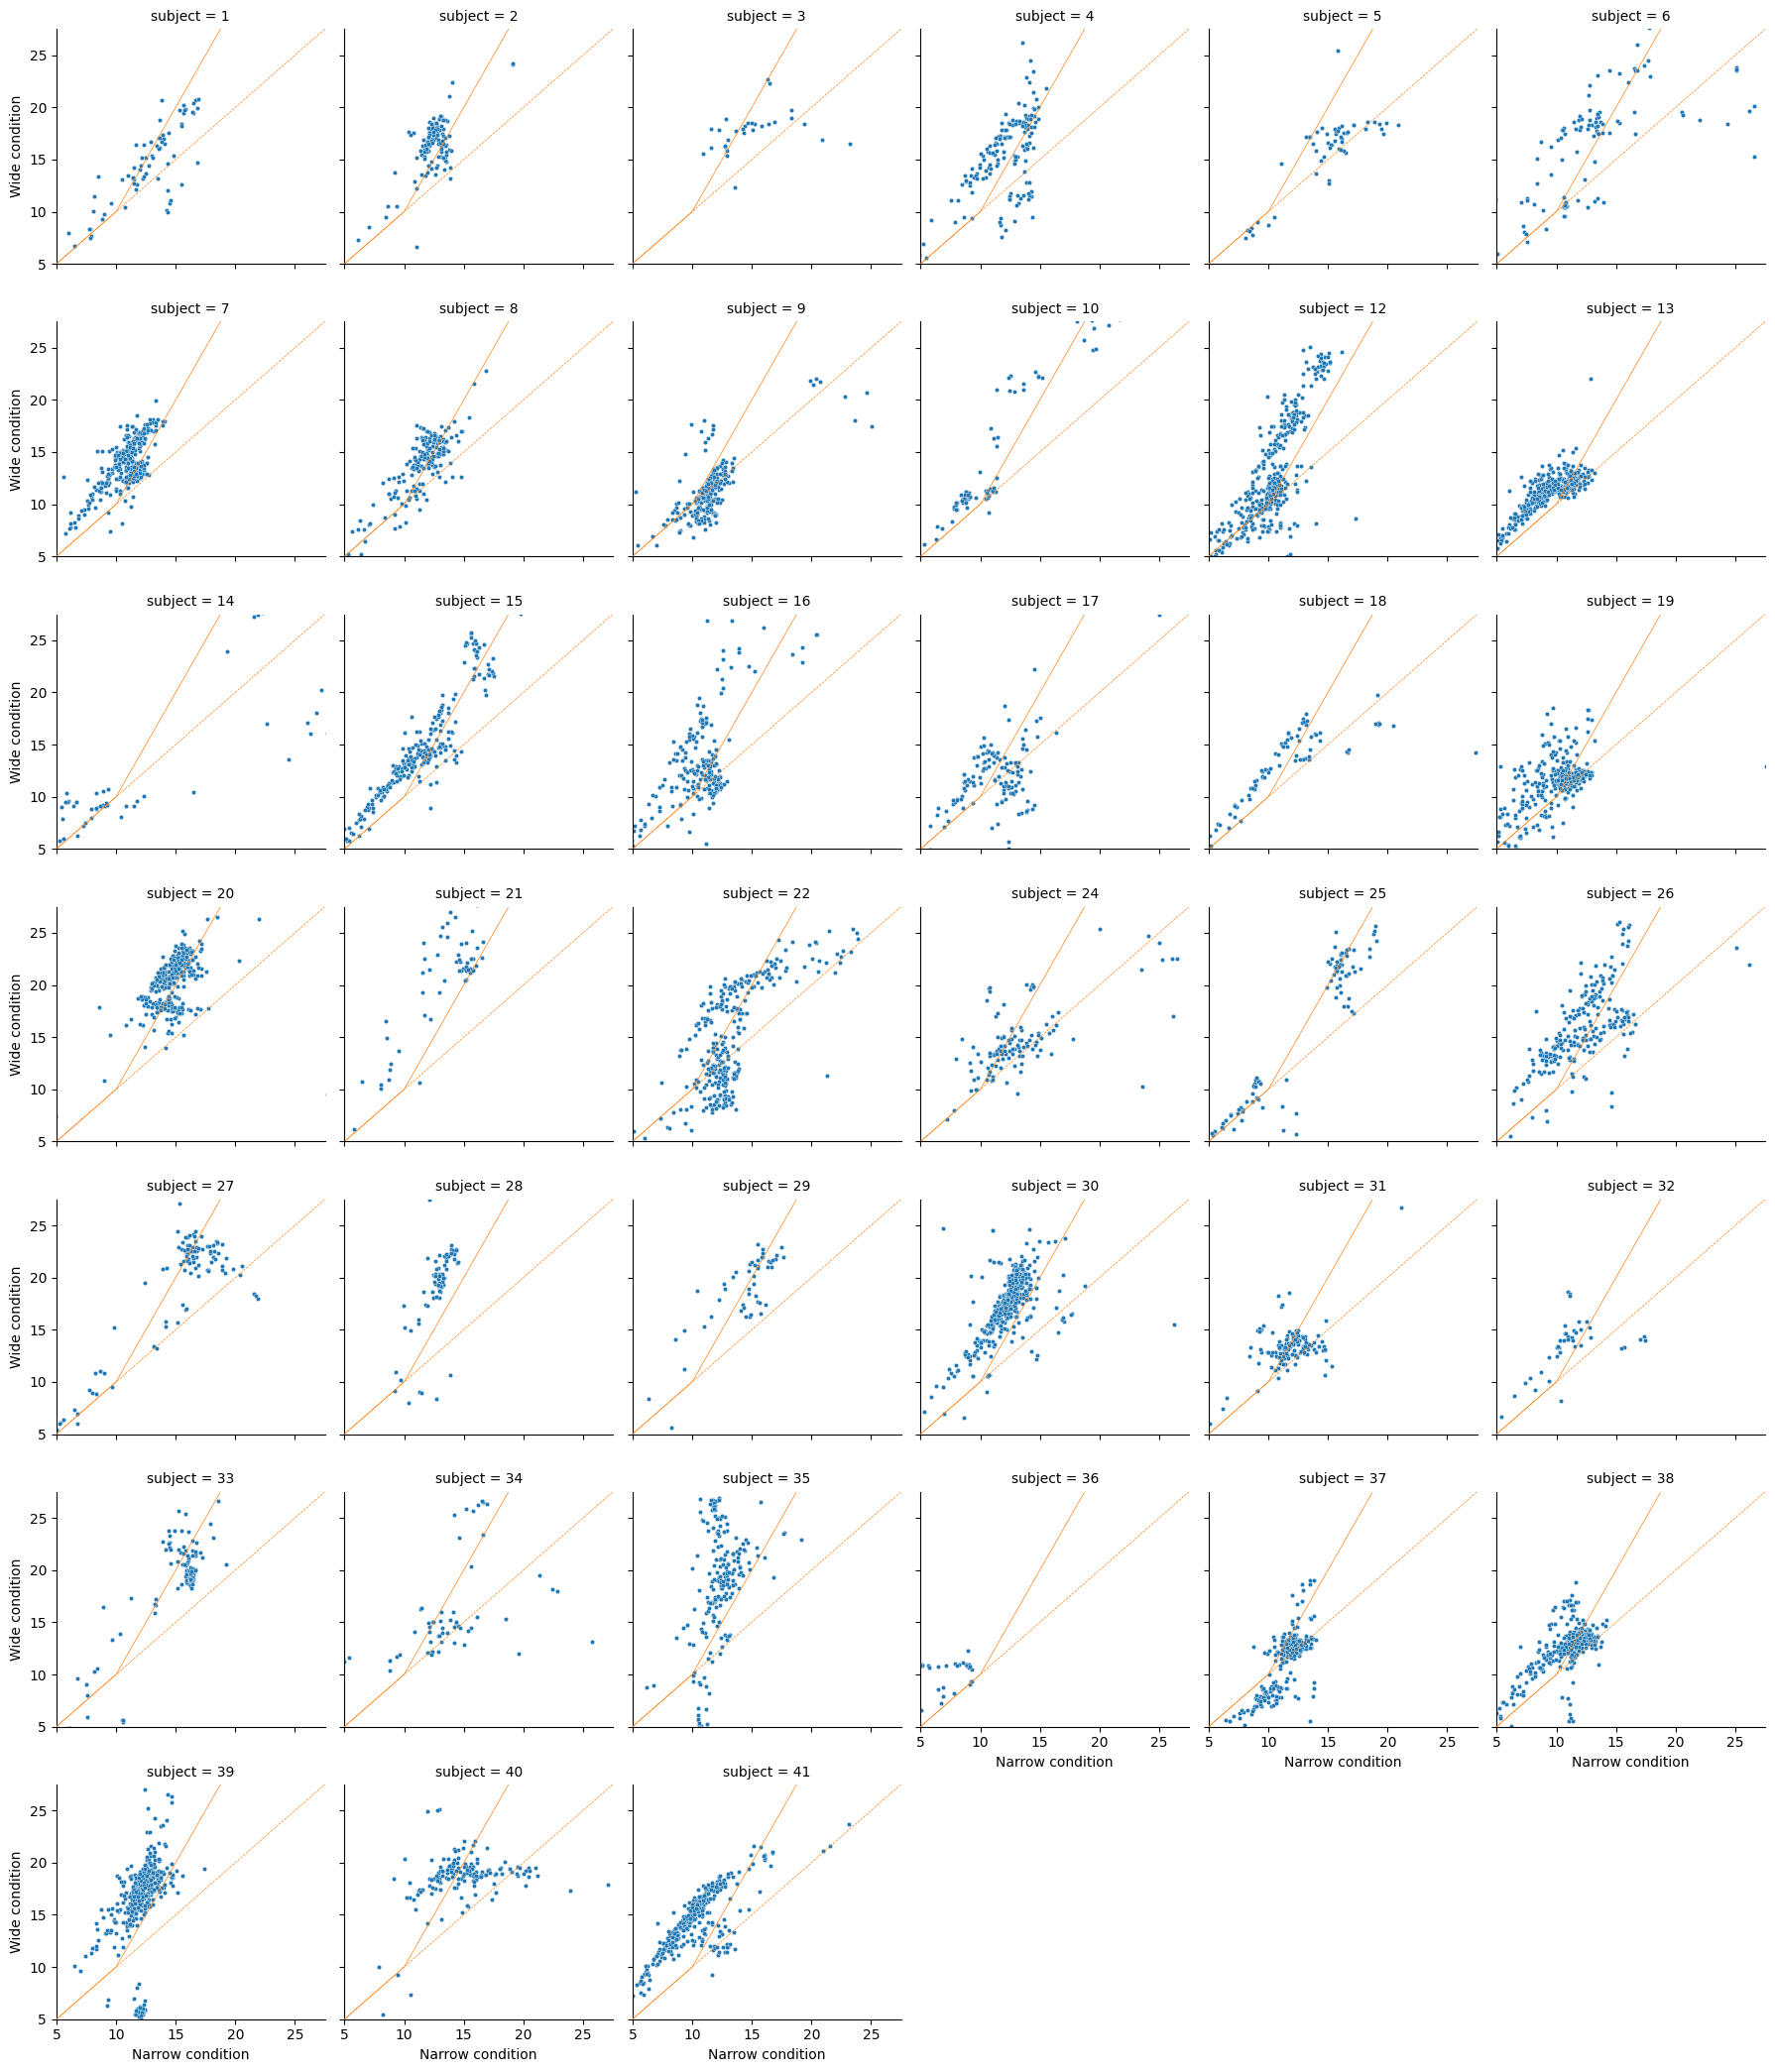

In [34]:
df_plt = df3.reset_index()
g = sns.FacetGrid(df_plt, col="subject", col_wrap=6, height=3, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x=('mu', 'narrow'), y=('mu', 'wide'),
                color='C0', s=10, alpha=1,) # edgecolor=None)
g.set_axis_labels("Narrow condition", "Wide condition")
g.set(xlim=(5,27.5), ylim=(5,27.5))
for ax in g.axes.flatten():
    ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c='C1', lw=.5, zorder=100)
plt.tight_layout()
plt.show()

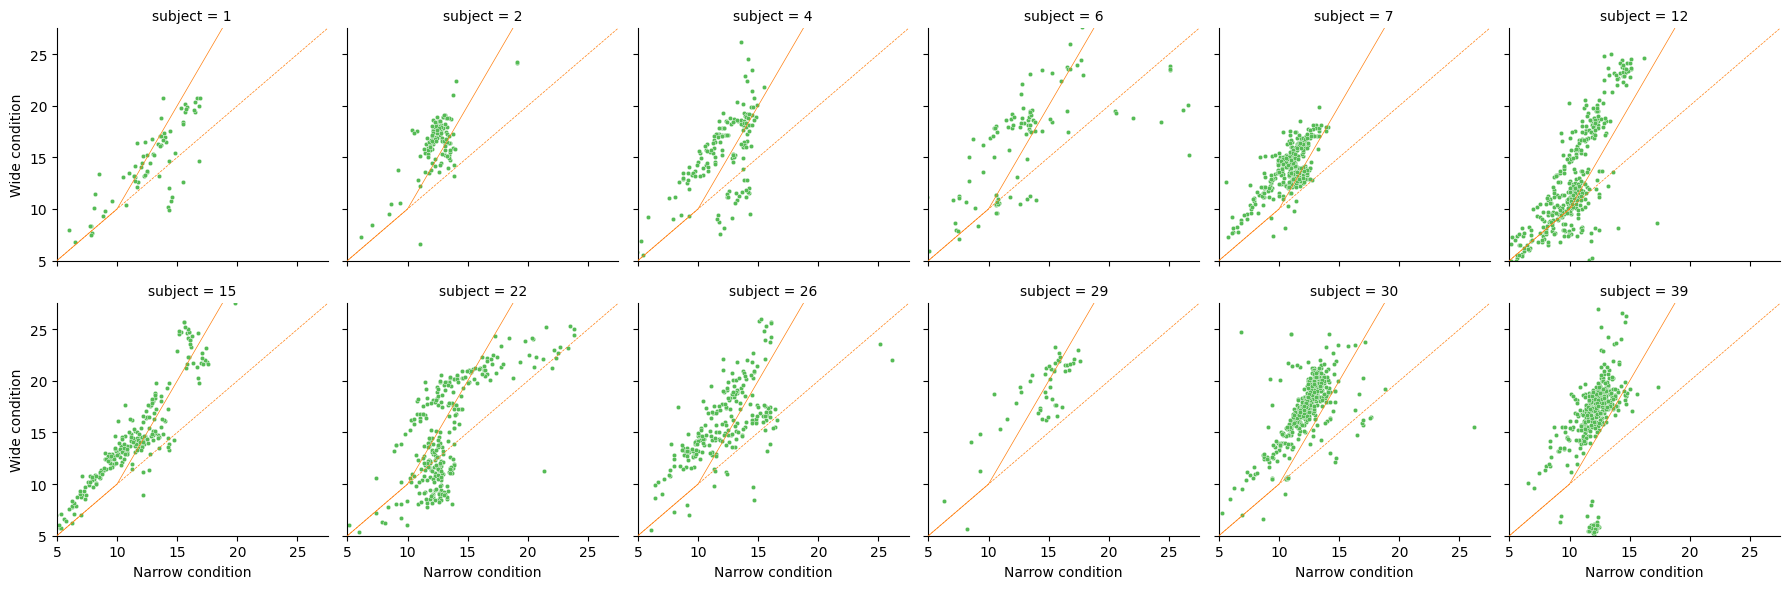

In [35]:
df_plt = index_filter(df3, subject=[1,2,4,6,7,12,15,22,26,29,30,39]).reset_index()
g = sns.FacetGrid(df_plt, col="subject", col_wrap=6, height=3, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x=('mu', 'narrow'), y=('mu', 'wide'),
                color=THIRD_COLOR, s=10, alpha=1,) # edgecolor=None)
g.set_axis_labels("Narrow condition", "Wide condition")
g.set(xlim=(5,27.5), ylim=(5,27.5))
for ax in g.axes.flatten():
    ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c='C1', lw=.5, zorder=100)
plt.tight_layout()
plt.show()

# Model 5 - subject-wise delta_wide

In [36]:
dfe5 = index_filter(pars, type='estimates', smoothed=True, model_label=5, ) 
dfgt5 = index_filter(pars, type='ground_truth', smoothed=True, model_label=5, ) 
dfe5  = dfe5[  dfe5[ ('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfgt5 = dfgt5[ dfgt5[('cvr2', 'nan')] > 0] #.drop(columns='alpha')

0.15619743 5.9677258 2.253248442820512 1.964078 0.18627692471764382
12
[0.         0.57142857 1.14285714 1.71428571 2.28571429 2.85714286 3.42857143 4.         4.57142857 5.14285714 5.71428571 6.28571429]
[0.28571429 0.85714286 1.42857143 2.         2.57142857 3.14285714 3.71428571 4.28571429 4.85714286 5.42857143 6.        ]


Text(1.914078, 2, 'median')

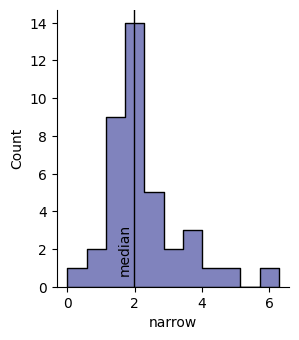

In [37]:
fig, ax = plt.subplots(figsize=(3, 3.6))
ratio_mu = dfe5.delta_wide.narrow.groupby('subject').first()
print(ratio_mu.min(), ratio_mu.max(), ratio_mu.mean(), ratio_mu.median(), ratio_mu.sem())
# nb_bins = 13
# dw = (ratio_mu.max() - ratio_mu.min()) / nb_bins
# bins = np.arange(2-dw/2-((2-ratio_mu.min()+.25)//dw)*dw, 6.+dw, dw)
#dw = .5
nb_bins_02 = 3
dw = 2 / (nb_bins_02 + 1/2)
#bins = np.arange(-dw/2, 7., dw)
bins = np.arange(0, ratio_mu.max()+dw, dw)
print(len(bins))
print(bins)
print( .5*(bins[:-1] + bins[1:]) )
sns.histplot(ratio_mu, bins=bins, ax=ax, color=plt.cm.Spectral_r(0.02), element='step', ec='k' ) # plt.cm.RdYlBu(0.4)
#sns.ecdfplot(ratio_mu, ax=ax, color='C0', linewidth=2, label='All subjects pooled')
sns.despine(fig)
#ax.axvline(2, color='k', linestyle='-', lw=1)
ax.axvline(ratio_mu.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_mu.median()-.05, 2, 'median', rotation=90, va='center', ha='right')

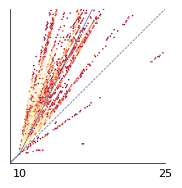

In [38]:
fig, ax = plt.subplots(figsize=(2,2))
this_df = dfe5
nmin_5, nmax_5 = 9, 25
ind = (dfe5.mu.narrow>=nmin_5) & (dfe5.mu.wide>=nmin_5) & (dfe5.mu.narrow<=nmax_5) & (dfe5.mu.wide<=nmax_5)
#sns.histplot(dfe5[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=1, alpha=1, color='grey')
cmap = plt.cm.RdYlBu #summer, YlOrRd_r , ---- 'RdYlBu', 'Spectral', 
ax.hexbin(dfe5[ind].mu.narrow, dfe5[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', bins='log')
ax.set_xlim(nmin_5,nmax_5); ax.set_ylim(nmin_5,nmax_5)
this_color = plt.cm.Spectral_r(0.02)
ax.axline((0,0), slope=1, color=this_color, ls='--', lw=.5, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c=this_color, lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.set_xlabel(None); ax.set_ylabel(None)
#ax.set_title('Free-slope model', fontsize=8)
ax.set_xticks([10,25]); ax.set_yticks([10,25]); ax.set_yticklabels([None,None]);
ax.tick_params(axis='both', labelsize=8, length=0)

In [39]:
np.arange(2-((2-ratio_mu.min())//dw+.5)*dw, 6.+dw, dw)

array([0.        , 0.57142857, 1.14285714, 1.71428571, 2.28571429, 2.85714286, 3.42857143, 4.        , 4.57142857, 5.14285714, 5.71428571,
       6.28571429])

0.15619743 5.9677258 2.253248442820512 1.964078


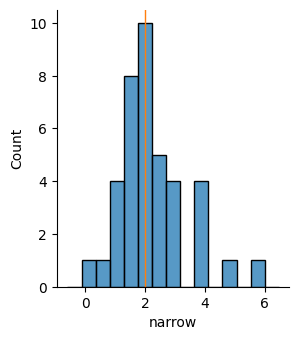

In [40]:
fig, ax = plt.subplots(figsize=(3, 3.6))
ratio_mu = dfe5.delta_wide.narrow.groupby('subject').first()
print(ratio_mu.min(), ratio_mu.max(), ratio_mu.mean(), ratio_mu.median())
dw = .47
sns.histplot(ratio_mu, bins=np.arange(2-(2//dw+1.5)*dw, 6.+dw, dw), ax=ax,)
#sns.ecdfplot(ratio_mu, ax=ax, color='C0', linewidth=2, label='All subjects pooled')
sns.despine(fig)
ax.axvline(2, color='C1', linestyle='-', lw=1)

In [41]:
print(sorted(ratio_mu))

[0.15619743, 0.70350844, 0.8750543, 1.2300447, 1.2550579, 1.2772125, 1.3105263, 1.3152603, 1.4615268, 1.5304906, 1.5347533, 1.6909493, 1.7168945, 1.7318991, 1.7733885, 1.8004893, 1.8084729, 1.926806, 1.9592503, 1.964078, 1.9716936, 2.0470965, 2.1359594, 2.1499162, 2.2576168, 2.268883, 2.3688104, 2.4932153, 2.6186748, 2.7392347, 2.8316061, 3.161634, 3.1662412, 3.9158642, 3.9571798, 3.9969351, 4.1041055, 4.7024364, 5.9677258]


# Figure - preferred numerosities

In [42]:
from matplotlib import rcParams

In [43]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.transforms as mtransforms

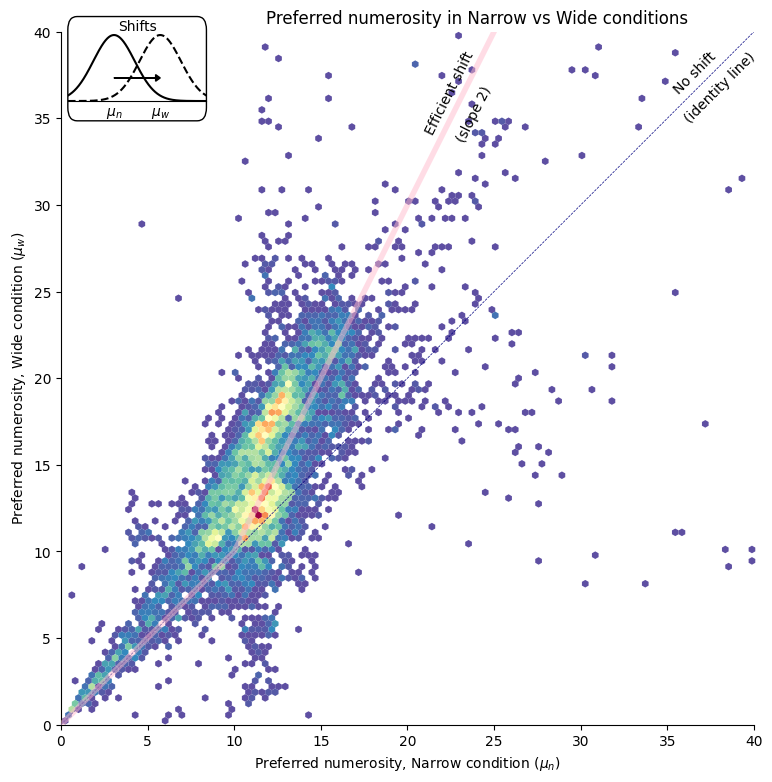

In [44]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect('equal') #, adjustable='box')
nmax = 40
ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) & (df3.mu.narrow<=nmax) & (df3.mu.wide<=nmax)
#sns.histplot(df3[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=.8, alpha=1, cmap='YlGnBu_r', thresh=0) # cmap='YlGnBu_r', 'plasma
#sns.kdeplot(df3[ind].mu, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
#ax.hexbin(df3[ind].mu.narrow, df3[ind].mu.wide, gridsize=(50*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap='YlGnBu_r', mincnt=1, edgecolors='none')
cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
ax.hexbin(df3[ind].mu.narrow, df3[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', clip_on=False)
#sns.regplot(df3[ind].mu, x='narrow', y='wide', ax=ax, scatter=False, lowess=True, color='#FF0000') # ci=None, 

ax.set_xlim(0,nmax); ax.set_ylim(0,nmax)
ax.axline((0,0), slope=1, color='navy', ls='--', lw=.5, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c="xkcd:pastel pink", alpha=.5, lw=4, zorder=100)
ax.set_xlabel('Preferred numerosity, Narrow condition ($\mu_n$)')
ax.set_ylabel('Preferred numerosity, Wide condition ($\mu_w$)')
ax.set_title('Preferred numerosity in Narrow vs Wide conditions', x=.6)
ax.text(38, 38+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
ax.text(40.25, 38+1, '(identity line)', fontsize=10, ha='right', va='top', rotation=45)
ax.text(24, 38+1, 'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43)
ax.text(25, 36+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43)

inset_width = 0.2; inset_height = .1
inset_ax = ax.inset_axes([0.01, 0.9, inset_width, inset_height], ) 
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
inset_ax.plot(xxs, np.exp(-(xxs-1)**2/.4), color='k') 
inset_ax.plot(xxs, np.exp(-(xxs-2)**2/.4), color='k', linestyle='--')
inset_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100)
inset_ax.set_ylim(0, None)
inset_ax.set_xlim(0, 3)
inset_ax.set_yticks([])
inset_ax.set_xticks([1,2])
inset_ax.set_xticklabels(['$\mu_n$', '$\mu_w$'])
inset_ax.tick_params(axis='x', length=0)
bb = mtransforms.Bbox([[0., -.3], [3, 1.28]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
inset_ax.add_patch(fancy)
inset_ax.set_title('Shifts', fontsize=10, y=.9, ha='center')

sns.despine(fig)
sns.despine(ax=inset_ax, left=True)
#ax.grid()
#fig.savefig('figures/mu_wide_vs_narrow.pdf', bbox_inches='tight')

In [45]:
from matplotlib.patches import ConnectionPatch

In [46]:
#THIRD_COLOR = '#EEFFEE'
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10

98.06% of voxels have 0 <= mu (narrow) <= 40 and 0 <= mu (wide) <= 40
1.94% of voxels have mu (narrow) or mu (wide) outside [0, 40]
37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.983, p = 6.16e-11, dof = 38
16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$
               T  dof alternative     p-val       CI95%   cohen-d   BF10     power
T-test  2.592253   38     greater  0.006729  [0.0, inf]  0.053155  6.392  0.093623


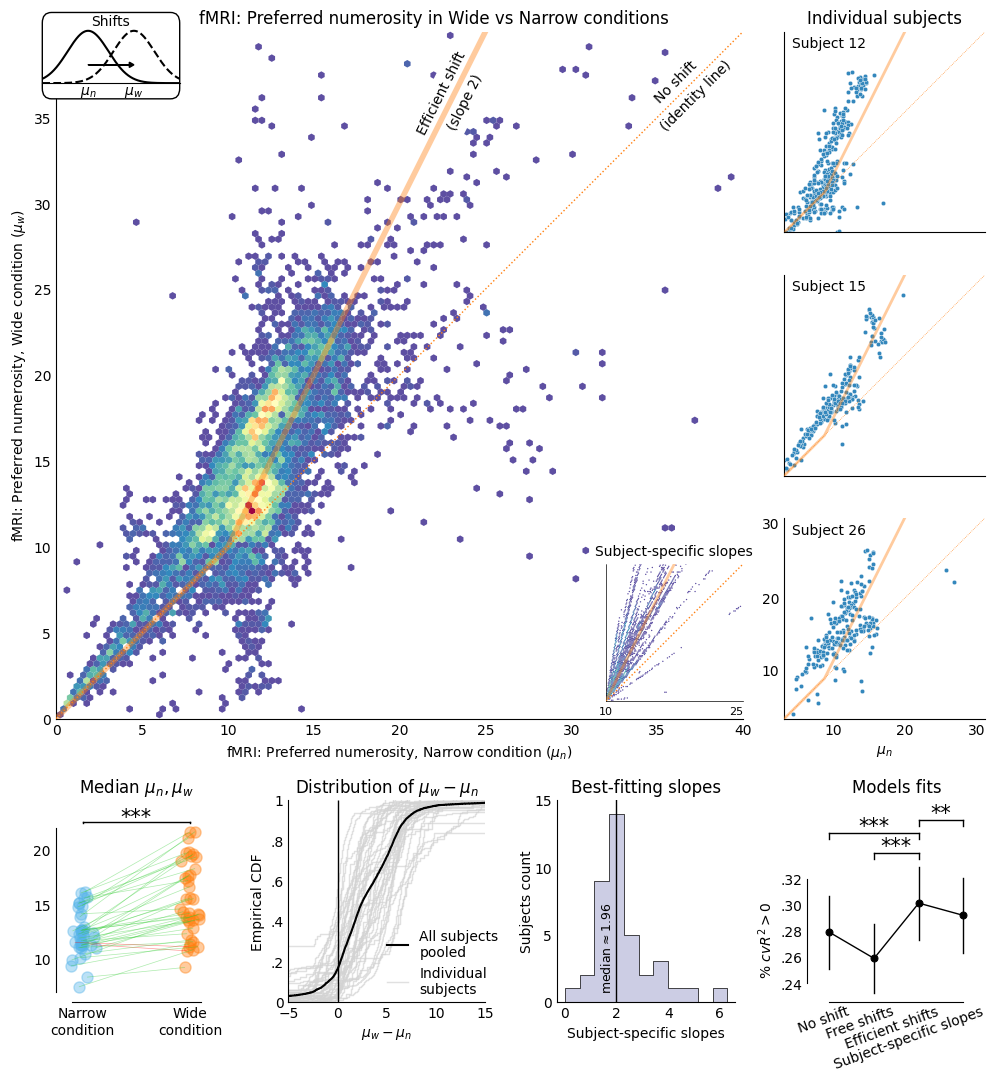

In [47]:
nrows = 4
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
MUMU_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'C1'

nmax = 40
ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) & (df3.mu.narrow<=nmax) & (df3.mu.wide<=nmax)
print(f'{ind.mean()*100:.2f}% of voxels have 0 <= mu (narrow) <= {nmax} and 0 <= mu (wide) <= {nmax}')
print(f'{(~ind).mean()*100:.2f}% of voxels have mu (narrow) or mu (wide) outside [{0}, {nmax}]')
#sns.histplot(df3[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=1, alpha=1, color=MUMU_COLOR, kde=True)
#sns.kdeplot(df3[ind].mu, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
ax.hexbin(df3[ind].mu.narrow, df3[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0.,
          cmap=cmap, mincnt=1, edgecolors='none', clip_on=False)
#sns.scatterplot(df3[ind].mu, x='narrow', y='wide', ax=ax, color=MUMU_COLOR, s=1)
#sns.kdeplot(df3[ind].mu, x='narrow', y='wide', ax=ax, levels=8, thresh=.1, fill=False, cmap='YlGnBu_r')
#sns.regplot(df3[ind].mu, x='narrow', y='wide', ax=ax, scatter=False, line_kws={'color': LINE_COLOR, 'lw': .5}, lowess=True) # ci=None, 

# ns = np.arange(0, 26, 1)
# ys = [ df3[(df3.mu.narrow>=n-.5) & (df3.mu.narrow<=n+.5)].mu.wide.mean() for n in ns]
# ysems = [ df3[(df3.mu.narrow>=n-.5) & (df3.mu.narrow<=n+.5)].mu.wide.sem() for n in ns]
# ax.errorbar(ns, ys, yerr=ysems, color='#FF0000', lw=2, zorder=100)

ax.set_xlim(0,nmax); ax.set_ylim(0,nmax)
ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
ax.set_xlabel('fMRI: Preferred numerosity, Narrow condition ($\mu_n$)')
ax.set_ylabel('fMRI: Preferred numerosity, Wide condition ($\mu_w$)')
ax.set_title('fMRI: Preferred numerosity in Wide vs Narrow conditions', x=.55, y=1.)
ax.text(37.5, 37.5+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
ax.text(39.5, 37.5+1, '(identity line)', fontsize=10, ha='right', va='top', rotation=45)
ax.text(24, 38+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
ax.text(25, 36.7+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(22.5, 35+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(23.5, 33.7+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43)
#ax.grid()
ax.set_yticks([0,5,10,15,20,25,30,35])

ax.tick_params(axis='both', length=0)

sns.despine(fig)

##### Icon
icon_width = 0.2; icon_height = .08
icon_ax = ax.inset_axes([-.02, 0.925, icon_width, icon_height], ) 
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1)**2/.4), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-2)**2/.4), color='k', linestyle='--')
icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100)
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([1,2])
icon_ax.set_xticklabels(['$\mu_n$', '$\mu_w$'])
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Shifts', fontsize=10, y=.9, ha='center')


if True:
    inset_width = 0.2
    #### Inset KDE
    # inset_ax = ax.inset_axes([0.575, 0.025, inset_width, inset_width], aspect='equal') 
    # sns.kdeplot(df3[ind].mu, x='narrow', y='wide', ax=inset_ax, levels=6, cmap=cmap, thresh=.15, linewidths=.8)
    # inset_ax.set_xlim(9,25); inset_ax.set_ylim(9,25)
    # inset_ax.axline((0,0), slope=1, color=LINE_COLOR, ls='--', lw=.5, zorder=100)
    # inset_ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=.5, zorder=100)
    # inset_ax.spines['top'].set_visible(False); inset_ax.spines['right'].set_visible(False)
    # inset_ax.spines['left'].set_linewidth(0.5); inset_ax.spines['bottom'].set_linewidth(0.5)
    # inset_ax.set_xlabel(None); inset_ax.set_ylabel(None)
    # inset_ax.set_xticks([10,25]); inset_ax.set_yticks([10, 25]); inset_ax.set_yticklabels([None,None]); #inset_ax.set_xticklabels([None,None]); 
    # inset_ax.tick_params(axis='both', labelsize=8, length=0)
    # inset_ax.get_xticklabels()[-1].set_ha('right')

    ### Inset Model 5
    inset_ax2 = ax.inset_axes([0.8, 0.025, inset_width, inset_width], aspect='equal')
    this_df = dfe5
    nmin_5, nmax_5 = 10, 25
    ind = (dfe5.mu.narrow>=nmin_5) & (dfe5.mu.wide>=nmin_5) & (dfe5.mu.narrow<=nmax_5) & (dfe5.mu.wide<=nmax_5)
    #sns.histplot(dfe5[ind].mu, x='narrow', y='wide', bins=161, ax=inset_ax2, pmax=.8, cmap=plt.cm.Spectral_r ) #alpha=.4, color=THIRD_COLOR)
    this_cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', # plt.cm.RdYlBu #
    inset_ax2.hexbin(dfe5[ind].mu.narrow, dfe5[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=this_cmap, mincnt=1, edgecolors='none', ) #bins='log')
    inset_ax2.set_xlim(nmin_5,nmax_5); inset_ax2.set_ylim(nmin_5,nmax_5)
    inset_ax2.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    inset_ax2.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    inset_ax2.spines['top'].set_visible(False)
    inset_ax2.spines['right'].set_visible(False)
    inset_ax2.spines['left'].set_linewidth(0.5)
    inset_ax2.spines['bottom'].set_linewidth(0.5)
    inset_ax2.set_xlabel(None); inset_ax2.set_ylabel(None)
    #inset_ax2.set_title('Free-slope model', fontsize=8)
    inset_ax2.set_xticks([10,25]); inset_ax2.set_yticks([10,25]); inset_ax2.set_yticklabels([None,None]);
    inset_ax2.tick_params(axis='both', labelsize=8, length=0)
    inset_ax2.get_xticklabels()[-1].set_ha('right')
    inset_ax2.set_title('Subject-specific slopes', backgroundcolor='w', fontsize=10)



###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(df3, subject=12).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(df3, subject=15).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(df3, subject=26).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=.5, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    ax.set_xlim(5, 30); ax.set_ylim(5, 30)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.text(20, 10, f'Subject {select_subjs[ii]}', fontsize=10)
    ax.text(6, 28, f'Subject {select_subjs[ii]}', fontsize=10, ha='left')
axS1.set_title('Individual subjects')
#axS3.set_xticks([5, 10, 15, 20, 25, 30]); axS3.set_yticks([5, 10, 15, 20, 25, 30]);
axS3.set_xticks([10,20,30]); axS3.set_yticks([10,20,30]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\mu_n$')

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

######## Median preferred numerosities
ax = fig.add_subplot(gs2[3,0])

mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
#ax.set_title("Median preferred num.")
ax.set_title("Median $\mu_n, \mu_w$")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(6.1,24.5) #23.9)
# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
# ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
star_line(ax, 1, 2, 22.5, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.5)

ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds((7, 22))
ax.spines.bottom.set_bounds((.9, 2.1))

######## CDF of change in preferred numerosity
ax = fig.add_subplot(gs2[3,1])
all_data = []
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
subjects = df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = df3.xs(subject, level='subject')[('mu', 'delta_wn')]
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
# Plot the pooled CDF (all subjects together) in a bold color
this_color = 'k'; this_lw = 1.5
sns.ecdfplot(data=all_data, x='mu_delta_wn', color=this_color, linewidth=this_lw, label='All subjects pooled', ax=ax, legend=False) # THIRD_COLOR
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )
ax.set_title("Distribution of $\mu_{w} - \mu_{n}$")
#ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\mu_{w} - \mu_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0),
                    handlelength=1.5, frameon=False)
ax.set_xlim(-5, 15)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
ax.tick_params(axis='both', length=0)


########### Distribution delta_wide
ax = fig.add_subplot(gs2[3,2])
ratio_mu = dfe5.delta_wide.narrow.groupby('subject').first()
nb_bins_02 = 3
dw = 2 / (nb_bins_02 + 1/2)
bins = np.arange(0, ratio_mu.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_mu, bins=bins, ax=ax, color=this_color, linewidth=.5, element='step', ec='k') # plt.cm.RdYlBu(0.4)
ax.set_title("Best-fitting slopes")
ax.set_xlabel('Subject-specific slopes')
ax.set_yticks([0, 5, 10, 15])
ax.set_ylabel('Subjects count', labelpad=0)
ax.tick_params(axis='both', length=0)
# ax.axvline(2, color=LINE_COLOR, linestyle='-', lw=1)
ax.axvline(ratio_mu.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_mu.median()-.05, 4., f'median$\\approx${ratio_mu.median():.2f}', rotation=90, va='center', ha='right', fontsize=9)


########## Proportion cvR2>0
ax = fig.add_subplot(gs2[3,3])
modelz = dict( [(0, 'No shift'), (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Subject-specific slopes')] )
these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax) # THIRD_COLOR
ax.set_xlabel(None)
#### x ticks labels positions
ax.tick_params(axis='both', length=0)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.24, .26, .28, .3, .32])
ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
#ax.set_ylim(.23, .33)
ax.spines.left.set_bounds((.24, .32))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.0025
star_line(ax, 0, 2, .355, compare_res_est.loc[(0,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .340, compare_res_est.loc[(3,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
#star_line(ax, 3, 2, .365, compare_res_est.loc[(4,5)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
onesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True, alternative='greater')
star_line(ax, 3, 2, .365, onesided_test.iloc[0]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
print(onesided_test)
ax.set_title('Models fits')
ax.set_ylim(None, .38)

sns.despine(fig)
sns.despine(ax=icon_ax, left=True)

fig.savefig('figures/mu_wide_vs_narrow.pdf', bbox_inches='tight')

In [48]:
ratio_mu.median()

1.964078

In [49]:
1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) )

array([0.73391772, 0.74145329, 0.86242215])

In [50]:
compare_res_est.loc[(3,4)]['p-val']

5.234140693771027e-10

In [51]:
1./np.sqrt(1+(np.pi**2/8)*.9*.1)

0.9487166248873418

In [52]:
#df3[ind]nmax = 40
#ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) & (df3.mu.narrow<=nmax) & (df3.mu.wide<=nmax)
delta = .5
print( df3[(df3.mu.narrow>=15-delta) & (df3.mu.narrow<=15+delta)].mu.wide.mean() )
print( df3[(df3.mu.narrow>=15-delta) & (df3.mu.narrow<=15+delta)].mu.wide.sem() )
#pg.ttest(df3[(df3.mu.narrow>=14.75) & (df3.mu.narrow<=15.25)].mu.wide, 15, alternative='two-sided')

20.053429095170454
0.188225206238157


In [53]:
((df3.mu.narrow>25)).mean()

0.023851148851148852

In [54]:
((df3.mu.narrow<10) & (df3.mu.wide<=10)).mean()

0.12712287712287712

37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.983, p = 6.16e-11, dof = 38
16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$


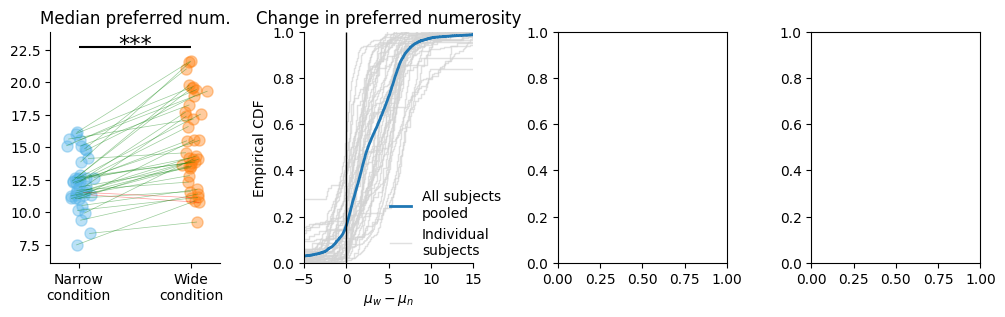

In [55]:
######## Bottom row
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

######## Median preferred numerosities
ax = axs[0]
mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median preferred num.")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(6.1,23.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')


######## CDF of change in preferred numerosity
ax = axs[1]
all_data = []
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
subjects = df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = df3.xs(subject, level='subject')[('mu', 'delta_wn')]
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x='mu_delta_wn', color='C0', linewidth=2, label='All subjects pooled', ax=ax)
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )

#plt.title("Empirical CDF of $\mu_{w} - \mu_{n}$")
ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\mu_{w} - \mu_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color='C0', lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
ax.set_xlim(-5, 15)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.subplots_adjust(wspace=0.5)

#fig.savefig('figures/bottom_row.pdf', bbox_inches='tight')

# Model 14 (free sds)

In [56]:
dfgt14 = index_filter(pars, type='ground_truth', smoothed=True, model_label=14)
dfgt14 = dfgt14[ dfgt14[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfgt14.index.rename(['subject', 'voxel'], inplace=True)
dfgt14

dfest14 = index_filter(pars, type='estimates', smoothed=True, model_label=14)
dfest14 = dfest14[ dfest14[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfest14.index.rename(['subject', 'voxel'], inplace=True)
dfest14

parameter             mu                   sd           delta_wide      amplitude            baseline                  r2      cvr2
range             narrow       wide    narrow      wide     narrow wide    narrow      wide    narrow      wide       nan       nan
subject voxel                                                                                                                      
1       10     12.181757  14.363514  0.692355  1.001164        2.0  2.0  1.356081  1.356081 -1.472868 -1.472868  0.024319  0.007944
        13     11.979450  13.958900  0.401673  0.546460        2.0  2.0  0.632903  0.632903 -0.612679 -0.612679  0.029108  0.008833
        16     11.622056  13.244112  0.359948  0.441931        2.0  2.0  0.422997  0.422997 -0.392825 -0.392825  0.023620  0.000943
        19     10.287462  10.574924  0.395287  0.442017        2.0  2.0  0.400638  0.400638 -0.349652 -0.349652  0.026793  0.001557
        20     10.003069  10.006138  0.572352  0.672433        2.0  2.0  0.665699  0.665699 -0.738390 -0.738390  0.029158  0.010135
...                  ...        ...       ...       ...        ...  ...       ...       ...       ...       ...       ...       ...
41      684    15.565413  21.130827  0.095523  0.149099        2.0  2.0  0.279757  0.279757  0.164614  0.164614  0.041674  0.016693
        686    11.275817  12.551634  0.311528  0.221549        2.0  2.0  0.315620  0.315620 -0.230035 -0.230035  0.027359  0.002267
        687    11.196170  12.392340  0.310941  0.198242        2.0  2.0  0.332232  0.332232 -0.056568 -0.056568  0.031147  0.004594
        689    13.385760  16.771520  0.743725  1.033240        2.0  2.0  0.764908  0.764908 -0.328955 -0.328955  0.027378  0.002505
        691    13.528701  17.057402  0.654947  0.945158        2.0  2.0  0.603408  0.603408 -0.276618 -0.276618  0.021567  0.002261

[8827 rows x 12 columns]

In [57]:
# dfest14[('sd_nat', 'narrow')] = dfest14.mu.narrow * np.sqrt( np.exp(dfest14.sd.narrow**2) - 1 )
# dfest14[('sd_nat', 'wide')] = dfest14.mu.wide * np.sqrt( np.exp(dfest14.sd.wide**2) - 1 )
# dfgt14[('sd_nat', 'narrow')] = dfgt14.mu.narrow * np.sqrt( np.exp(dfgt14.sd.narrow**2) - 1 )
# dfgt14[('sd_nat', 'wide')] = dfgt14.mu.wide * np.sqrt( np.exp(dfgt14.sd.wide**2) - 1 )

# dfest14[('fwhm_nat', 'narrow')] = 2 * dfest14.mu.narrow * np.sinh(dfest14.sd.narrow * np.sqrt(2 * np.log(2)))
# dfest14[('fwhm_nat', 'wide')]   = 2 * dfest14.mu.wide * np.sinh(dfest14.sd.wide * np.sqrt(2 * np.log(2)))
# dfgt14[('fwhm_nat', 'narrow')]  = 2 * dfgt14.mu.narrow * np.sinh(dfgt14.sd.narrow * np.sqrt(2 * np.log(2)))
# dfgt14[('fwhm_nat', 'wide')]    = 2 * dfgt14.mu.wide * np.sinh(dfgt14.sd.wide * np.sqrt(2 * np.log(2)))

In [58]:
(dfest14[dfest14.mu.narrow>=10].mu.wide-10) / (dfest14[dfest14.mu.narrow>=10].mu.narrow-10)

subject  voxel
1        10       2.0
         13       2.0
         16       2.0
         19       2.0
         20       2.0
                 ... 
41       684      2.0
         686      2.0
         687      2.0
         689      2.0
         691      2.0
Length: 7104, dtype: float64

In [59]:
print( pg.corr( dfgt14.sd.narrow, dfgt14.sd.wide ) )
dfgt14.groupby(level='subject').apply(lambda g: pg.corr(g.sd.narrow, g.sd.wide)).describe(percentiles=[.5, .75, .8, .85, .9])

            n         r         CI95%          p-val       BF10  power
pearson  7977  0.267562  [0.25, 0.29]  7.700274e-131  5.64e+126    1.0


,n,r,p-val,power
count,39.000000,39.000000,3.900000e+01,39.000000
mean,204.538462,0.451255,9.699116e-02,0.805335
std,149.559150,0.294165,2.446443e-01,0.334157
min,23.000000,-0.104010,3.626308e-207,0.051341
50%,160.000000,0.476561,2.168226e-09,0.999987
75%,314.000000,0.597017,2.119924e-02,1.000000
80%,381.600000,0.689621,4.779332e-02,1.000000
85%,406.200000,0.803924,1.227947e-01,1.000000
90%,428.600000,0.854947,2.880994e-01,1.000000
max,498.000000,0.982038,9.046241e-01,1.000000


In [60]:
print( pg.corr( dfest14.sd.narrow, dfest14.sd.wide ) )
dfest14.groupby(level='subject').apply(lambda g: pg.corr(g.sd.narrow, g.sd.wide)).describe(percentiles=[.5, .75, .8, .85, .9])

            n         r         CI95%          p-val        BF10  power
pearson  8827  0.232262  [0.21, 0.25]  1.958039e-108  2.352e+104    1.0


,n,r,p-val,power
count,39.000000,39.000000,3.900000e+01,39.000000
mean,226.333333,0.550051,9.329555e-02,0.834962
std,148.421401,0.332374,2.302159e-01,0.332600
min,44.000000,-0.034489,1.843030e-278,0.050922
50%,171.000000,0.511777,2.858754e-13,1.000000
75%,332.000000,0.892801,1.769752e-04,1.000000
80%,386.200000,0.933473,7.218613e-03,1.000000
85%,425.900000,0.951133,1.238829e-01,1.000000
90%,447.800000,0.967121,5.077764e-01,1.000000
max,535.000000,0.983901,9.216275e-01,1.000000


In [61]:
# print( pg.corr( dfgt14.fwhm_nat.narrow, dfgt14.fwhm_nat.wide ) )
# dfgt14.groupby(level='subject').apply(lambda g: pg.corr(g.fwhm_nat.narrow, g.fwhm_nat.wide)).describe(percentiles=[.5, .75, .8, .85, .9])

In [62]:
# print( pg.corr( dfest14.fwhm_nat.narrow, dfest14.fwhm_nat.wide ) )
# dfest14.groupby(level='subject').apply(lambda g: pg.corr(g.fwhm_nat.narrow, g.fwhm_nat.wide)).describe(percentiles=[.5, .75, .8, .85, .9])

In [63]:
for zz in ['sd',]: # 'sd_nat', 'fwhm_nat']:
    dfgt14[zz, 'delta_wn'] = dfgt14[zz, 'wide'] - dfgt14[zz, 'narrow']
    dfgt14[zz, 'ratio_wn'] = dfgt14[zz, 'wide'] / dfgt14[zz, 'narrow']
    dfest14[zz, 'delta_wn'] = dfest14[zz, 'wide'] - dfest14[zz, 'narrow']
    dfest14[zz, 'ratio_wn'] = dfest14[zz, 'wide'] / dfest14[zz, 'narrow']

32 subjects have median $\sigma$ in Wide condition larger than in Narrow condition
7 subjects have median $\sigma$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -6.268, p = 2.44e-07, dof = 38


/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_95232/2538833436.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")


Text(1.5, 1.4725, '***')

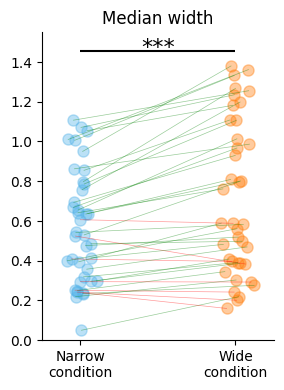

In [64]:
# Compute per-subject medians for 'mu' in 'wide' and 'narrow'
#nmax = 40
this_df = dfest14
#ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=0) & (this_df.mu.wide>=0) & (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
sd_wide_medians = this_df[('sd', 'wide')].groupby('subject').median()
sd_narrow_medians = this_df[('sd', 'narrow')].groupby('subject').median()
print( (sd_wide_medians >= sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition larger than in Narrow condition' )
print( (sd_wide_medians <  sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition smaller than in Narrow condition' )

fig, ax = plt.subplots(figsize=(3, 4))
paired_strip_plot(ax, x1=1, x2=2, y1=sd_narrow_medians, y2=sd_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median width")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(0.,1.55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# paired test
paired_test = pg.ttest(sd_narrow_medians, sd_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.94*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.95*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')

#fig.savefig('figures/delta_median_sd.pdf', bbox_inches='tight')

22.544465843434917 % of voxels have $\sigma_{w} - \sigma_{n} < 0$


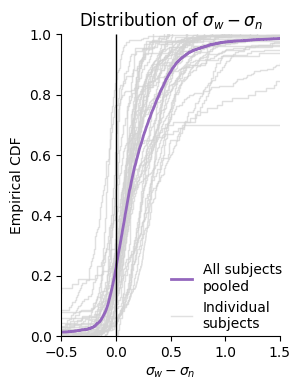

In [65]:
fig, ax = plt.subplots(figsize=(3, 4))
all_data = []
this_df = dfest14
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
qty = 'delta' # delta or ratio
subjects = this_df.index.get_level_values('subject').unique()
for subject in subjects:
    data = this_df.xs(subject, level='subject')[('sd', f'{qty}_wn')]
    all_data.append(pd.DataFrame({f'sd_{qty}_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x=f'sd_{qty}_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x=f'sd_{qty}_wn', color=FOURTH_COLOR, linewidth=2, label='All subjects pooled')
print( (all_data.sd_delta_wn<0).mean() * 100, '% of voxels have $\sigma_{w} - \sigma_{n} < 0$' )

#plt.title("Empirical CDF of $\sigma_{w} - \sigma_{n}$")
plt.gca().set_title("Distribution of $\sigma_{w} - \sigma_{n}$")
plt.xlabel('$\sigma_{w} - \sigma_{n}$')
plt.ylabel('Empirical CDF')
plt.legend(handles=[plt.Line2D([0], [0], color=FOURTH_COLOR, lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
plt.tight_layout()
if qty=='delta':
    plt.xlim(-.5, 1.5)
else:
    plt.xlim(0.5, 3.)
    #plt.vlines(np.sqrt(2), 0, 1, color='black', linestyle='-', lw=1)
plt.vlines(0 if qty=='delta' else 1, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#fig.savefig('figures/cdf_delta_sd.pdf', bbox_inches='tight')

2.435708621275632% of the data not shown in the figure (σ>3)


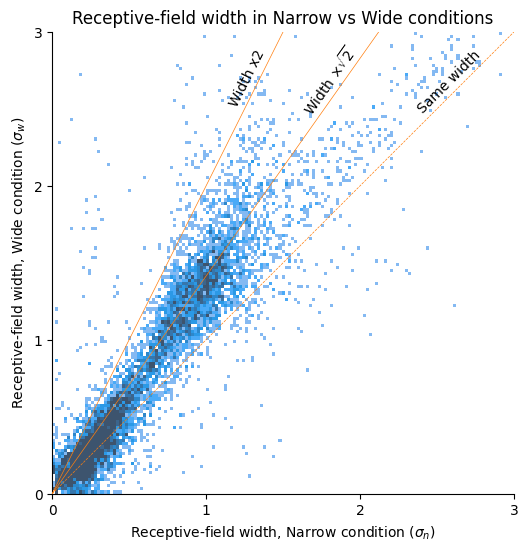

In [66]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal') #, adjustable='box')
#nmax = 40
this_df = dfest14
ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=10) & (this_df.mu.wide>=10) #& (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
#sns.displot(this_df[ind].mu, x='narrow', y='wide', kind='hist', bins=41)
sns.histplot(this_df[ind].sd, x='narrow', y='wide', bins=801, ax=ax, pmax=.6, alpha=1)
#sns.scatterplot(this_df[ind].mu, x='narrow', y='wide', color='C0', s=1, ax=ax, alpha=1, ec='none')
#sns.displot(this_df[ind].mu, x='narrow', y='wide', kind='kde', bins=41, ax=ax)
#sns.kdeplot(this_df[ind].mu, x='narrow', y='wide', ax=ax, levels=5, color='lightgrey', thresh=.1, linewidth=1, zorder=-1000)
σmax = 3
print( f'{( (this_df[ind].sd.narrow > σmax) | (this_df[ind].sd.wide > σmax) ).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)
ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
ax.plot([0, σmax], [0, 2*σmax], c='C1', lw=.5, zorder=100)
ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c='C1', lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Receptive-field width, Narrow condition ($\sigma_n$)')
ax.set_ylabel('Receptive-field width, Wide condition ($\sigma_w$)')
ax.set_title('Receptive-field width in Narrow vs Wide conditions')
ax.text(2.8, 2.8+.1, 'Same width', fontsize=10, ha='right', va='top', rotation=45)
ax.text(1.4, 2.8+.1, 'Width x2', fontsize=10, ha='right', va='top', rotation=63.43)
ax.text(2., 2.*np.sqrt(2)+.1, 'Width $\\times\sqrt{2}$', fontsize=10, ha='right', va='top', rotation=54.74)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);
# #ax.grid()
#fig.savefig('figures/sd_wide_vs_narrow.pdf', bbox_inches='tight')

KstestResult(statistic=0.10479211510139345, pvalue=1.3449304601018732e-42, statistic_location=0.1892282093172289, statistic_sign=-1)
KstestResult(statistic=0.07658321060382917, pvalue=6.262444195901533e-23, statistic_location=0.19185430278445154, statistic_sign=-1)


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.658235,8826,two-sided,1.577141e-08,"[0.05, 0.1]",0.074875,1.039e+05,1.0


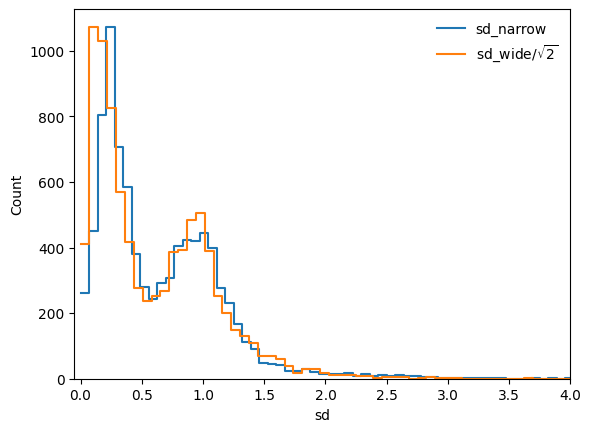

In [67]:
cu = False
dfx14 = dfest14
sns.histplot( dfx14.sd.narrow, label='sd_narrow', cumulative=cu, element='step', fill=False);
plt.gca().set_xlabel('sd')
sns.histplot( dfx14.sd.wide/np.sqrt(2), label='sd_wide$/\sqrt{2}$', cumulative=cu, element='step', fill=False)
plt.xlim(-.05,4); plt.legend()
print( stats.ks_2samp(dfx14.sd.narrow, dfx14.sd.wide/np.sqrt(2)))
print( stats.ks_2samp(dfx14.sd.narrow, dfx14.sd.wide/1.287794))
pg.ttest(x=dfx14.sd.narrow, y=dfx14.sd.wide/np.sqrt(2), paired=True)

# Model 15 (r_sd)

In [68]:
# Model 15 is better
# print(rez[14].mean(), rez[15].mean())
# print( pg.ttest(x=rez[14], y=rez[15], paired=True) )
# Model 15 is better than 14
print(rez_est[14].mean(), rez_est[15].mean())
pg.ttest(x=rez_est[14], y=rez_est[15], paired=True)
# Model 15 is better than 4
print(rez_est[4].mean(), rez_est[15].mean())
pg.ttest(x=rez_est[4], y=rez_est[15], paired=True)

0.2859119711697223 0.3155111920740877
0.30132535593290977 0.3155111920740877


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.653206,38,two-sided,0.011574,"[-0.03, -0.0]",0.080935,3.633,0.078252


In [69]:
dfest15 = index_filter(pars, type='estimates', smoothed=True, model_label=15)
dfest15 = dfest15[ dfest15[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfest15.index.rename(['subject', 'voxel'], inplace=True)
dfest15[('sd','ratio_wn')] = dfest15.sd.wide / dfest15.sd.narrow
dfest15

dfgt15 = index_filter(pars, type='ground_truth', smoothed=True, model_label=15)
dfgt15 = dfgt15[ dfgt15[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfgt15.index.rename(['subject', 'voxel'], inplace=True)
dfgt15[('sd','ratio_wn')] = dfgt15.sd.wide / dfgt15.sd.narrow
dfgt15

parameter             mu                   sd           delta_wide      amplitude            baseline                  r2      cvr2        sd
range             narrow       wide    narrow      wide     narrow wide    narrow      wide    narrow      wide       nan       nan  ratio_wn
subject voxel                                                                                                                                
1       10     11.706925  13.413851  0.114662  0.150516        2.0  2.0  0.698721  0.698721 -0.462405 -0.462405  0.044681  0.018702  1.312699
        13     11.599907  13.199814  0.116986  0.153567        2.0  2.0  0.659813  0.659813 -0.359337 -0.359337  0.049357  0.021686  1.312699
        14     11.700312  13.400623  0.103045  0.135268        2.0  2.0  0.601583  0.601583 -0.616483 -0.616483  0.035233  0.002891  1.312699
        16     11.356297  12.712593  0.127587  0.167484        2.0  2.0  0.464056  0.464056 -0.285340 -0.285340  0.036573  0.014237  1.312699
        17     11.470483  12.940966  0.106346  0.139600        2.0  2.0  0.579976  0.579976 -0.430054 -0.430054  0.045050  0.011577  1.312699
...                  ...        ...       ...       ...        ...  ...       ...       ...       ...       ...       ...       ...       ...
41      687    10.001306  10.002611  0.406871  0.560031        2.0  2.0  0.316199  0.316199 -0.112485 -0.112485  0.026977  0.007772  1.376434
        688    13.352640  16.705280  0.827879  1.139521        2.0  2.0  0.732903  0.732903 -0.568818 -0.568818  0.017233  0.010196  1.376433
        689    11.856775  13.713551  0.969636  1.334640        2.0  2.0  0.803345  0.803345 -0.389811 -0.389811  0.024026  0.010816  1.376433
        691    12.157406  14.314812  0.884795  1.217861        2.0  2.0  0.785061  0.785061 -0.468486 -0.468486  0.026154  0.015875  1.376433
        693    11.992874  13.985748  0.986476  1.357819        2.0  2.0  0.729405  0.729405 -0.585881 -0.585881  0.012501  0.004123  1.376434

[8785 rows x 13 columns]

In [70]:
rez_est.loc[:,[14,15]].mean()

model_label
14    0.285912
15    0.315511
dtype: float64

In [71]:
print( dfest15[('sd', 'ratio_wn')].groupby('subject').first().mean(), dfest15[('sd', 'ratio_wn')].groupby('subject').first().std() )
print( dfest15[('sd', 'ratio_wn')].groupby('subject').first().median() )
print( dfgt15 [('sd', 'ratio_wn')].groupby('subject').first().mean() )
print( dfgt15 [('sd', 'ratio_wn')].groupby('subject').first().median() )
np.sqrt(2)

1.304754457830862 0.24664963098064527
1.321174469451246
1.2877944588717374
1.309339674301479


1.4142135623730951

In [72]:
# test if the mean is significantly different from 1
print( stats.ttest_1samp(dfest15[('sd', 'ratio_wn')].groupby('subject').first(), 1) )
print( stats.ttest_1samp(dfgt15[('sd', 'ratio_wn')].groupby('subject').first(), 1) )

TtestResult(statistic=7.716172011244838, pvalue=2.6987830478430184e-09, df=38)
TtestResult(statistic=7.2300299295274275, pvalue=1.2036774014055539e-08, df=38)


In [73]:
# test if the mean is significantly different from sqrt(2)
print( stats.ttest_1samp(dfest15[('sd', 'ratio_wn')].groupby('subject').first(), np.sqrt(2) ) )
print( stats.ttest_1samp(dfgt15[('sd', 'ratio_wn')].groupby('subject').first(), np.sqrt(2) ) )
# ratio_wn_gt15 = dfgt15[('sd', 'ratio_wn')].groupby('subject').first()
# ratio_wn_est15 = dfest15[('sd', 'ratio_wn')].groupby('subject').first()
# Using bootstrap to test if the median is significantly different from sqrt(2) ?

TtestResult(statistic=-2.77142879174373, pvalue=0.008593168432867927, df=38)
TtestResult(statistic=-3.1759259909385356, pvalue=0.002961285029114354, df=38)


In [74]:
# test if the mean is significantly different from 2
print( stats.ttest_1samp(dfest15[('sd', 'ratio_wn')].groupby('subject').first(), 2) )
print( stats.ttest_1samp(dfgt15[('sd', 'ratio_wn')].groupby('subject').first(), 2) )

TtestResult(statistic=-17.60313608408512, pvalue=7.276866362959838e-20, df=38)
TtestResult(statistic=-17.892169983118098, pvalue=4.182052724464494e-20, df=38)


TtestResult(statistic=7.716172011244838, pvalue=2.6987830478430184e-09, df=38)


Text(0.5, 1.0, 'Sd ratio_wn parameter (Model 15)')

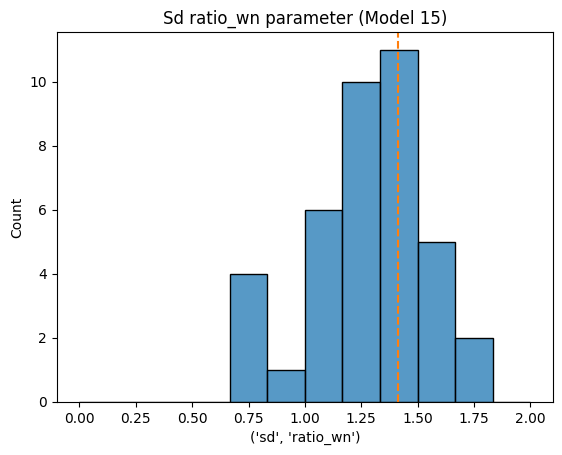

In [75]:
sns.histplot( dfgt15[('sd','ratio_wn')].groupby('subject').first(), bins=np.linspace(0,2,13))
plt.axvline(np.sqrt(2), ls='--', color='C1')
print( stats.ttest_1samp( dfest15[('sd','ratio_wn')].groupby('subject').first(), popmean=1) )
#stats.ttest_1samp( dfest15[('sd','ratio_wn')].groupby('subject').first(), popmean=np.sqrt(2))
plt.title('Sd ratio_wn parameter (Model 15)')

In [76]:
print( dfest15.sd.ratio_wn.groupby('subject').first().mean(), dfgt15.sd.ratio_wn.groupby('subject').first().mean() )
print( dfest15.sd.ratio_wn.groupby('subject').first().median(), dfgt15.sd.ratio_wn.groupby('subject').first().median() )

1.304754457830862 1.2877944588717374
1.321174469451246 1.309339674301479


1.304754457830862


count    39.000000
mean      1.304754
std       0.246650
min       0.808450
25%       1.177294
50%       1.321174
75%       1.406219
max       2.245313
Name: ratio_wn, dtype: float64

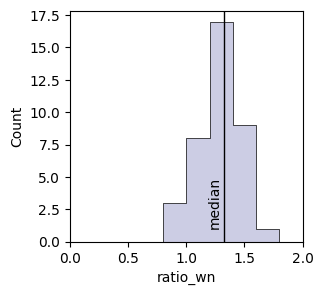

In [77]:
fig, ax = plt.subplots(figsize=(3, 3))
ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first()
print(ratio_sd.mean())
dw = .2
bins = np.arange(-dw, ratio_sd.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_sd, ax=ax, bins=bins, color=this_color, linewidth=.5, element='step', ec='k') # bins=bins, 
ax.set_xlim(0,2)
ax.axvline(ratio_sd.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_sd.median()-.02, 3, 'median', rotation=90, va='center', ha='right')
ratio_sd.describe()

0.2259190798932019% of the data not shown in the figure (σ>3)


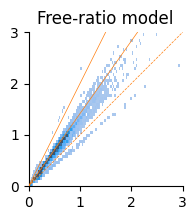

In [78]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.set_aspect('equal') #, adjustable='box')
nmax = 40
this_df = dfest15
ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=0) & (this_df.mu.wide>=0) & (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
#sns.displot(this_df[ind].sd, x='narrow', y='wide', kind='hist', bins=41)
sns.histplot(this_df[ind].sd, x='narrow', y='wide', bins=161, ax=ax, pmax=.6, alpha=1)
#sns.scatterplot(this_df[ind].sd, x='narrow', y='wide', color='C0', s=1, ax=ax, alpha=1, ec='none')
#sns.displot(this_df[ind].sd, x='narrow', y='wide', kind='kde', bins=41, ax=ax)
#sns.kdeplot(this_df[ind].sd, x='narrow', y='wide', ax=ax, levels=5, color='lightgrey', thresh=.1, linewidth=1, zorder=-1000)
σmax = 3
print( f'{( (this_df[ind].sd.narrow > σmax) | (this_df[ind].sd.wide > σmax) ).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)
ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
ax.plot([0, σmax], [0, 2*σmax], c='C1', lw=.5, zorder=100)
ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c='C1', lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_title('Free-ratio model')
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);
#ax.get_xticklabels()[-1].set_ha('right')
#ax.text(38, 38+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
#ax.text(24, 38+1, 'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43)
#ax.grid()
#fig.savefig('figures/sd_wide_vs_narrow_freeratio.pdf', bbox_inches='tight')

# Figure - widths

In [79]:
mean_ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first().mean()
mean_ratio_sd

1.304754457830862

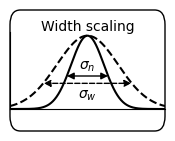

In [80]:
##### Icon
icon_width = 0.2; icon_height = .08
fig, icon_ax = plt.subplots(figsize=(2,1))
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.2), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.7), color='k', linestyle='--')
#icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100, )
icon_ax.annotate("", xytext=(1.05, .45), xy=(1.95, .45), arrowprops=dict(arrowstyle="<|-|>", color='k'))
icon_ax.annotate("", xytext=(.6, .35), xy=(2.4, .35), arrowprops=dict(arrowstyle="<|-|>", ls='--', color='k'))
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([])
#icon_ax.set_xticklabels(['$\sigma_n$', '$\sigma_w$'])
icon_ax.text(1.5, .475, '$\sigma_n$', fontsize=10, ha='center', va='bottom')
icon_ax.text(1.5, .275, '$\sigma_w$', fontsize=10, ha='center', va='top')
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Width scaling', fontsize=10, y=.9, ha='center')
sns.despine(ax=icon_ax)

In [81]:
ratio_sd.mean(), ratio_sd.median()

(1.304754457830862, 1.321174469451246)

2.435708621275632% of the data not shown in the figure (σ>3)
32 subjects have median $\sigma$ in Wide condition larger than in Narrow condition
7 subjects have median $\sigma$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -6.268, p = 2.44e-07, dof = 38
22.544465843434917 % of voxels have $\sigma_{w} - \sigma_{n} < 0$
1.304754457830862


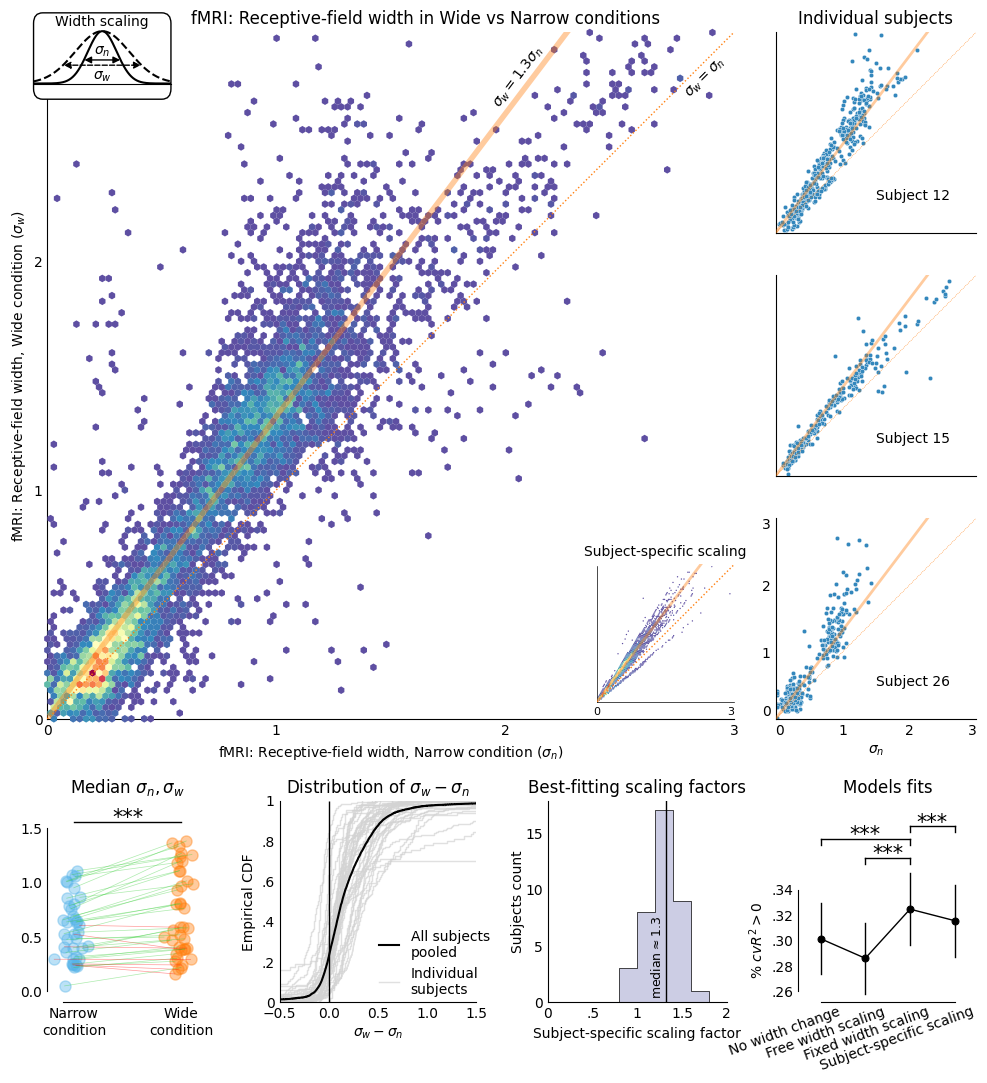

In [82]:
nrows = 4
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r #RdYlBu_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
SDSD_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'C1' 

σmax = 3
ind = (dfest14.sd.narrow <= σmax) & (dfest14.sd.wide <= σmax)
#sns.histplot(dfest14[ind].sd, x='narrow', y='wide', bins=801, ax=ax, pmax=.6, alpha=1, color=SDSD_COLOR)
#sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
ax.hexbin(dfest14[ind].sd.narrow, dfest14[ind].sd.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', clip_on=False, zorder=10)
#sns.scatterplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, color=SDSD_COLOR, s=1)
#sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, levels=8, thresh=.1, fill=False, cmap='YlGnBu_r')
#sns.regplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, scatter=False, line_kws={'color': LINE_COLOR, 'lw': .5}, lowess=True) # ci=None, 
print( f'{(~ind).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)

ax.tick_params(axis='both', length=0)

median_ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first().median()

ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
#ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)

ax.set_xlabel('fMRI: Receptive-field width, Narrow condition ($\sigma_n$)')
ax.set_ylabel('fMRI: Receptive-field width, Wide condition ($\sigma_w$)')
ax.set_title('fMRI: Receptive-field width in Wide vs Narrow conditions', x=.55, y=1)

ax.text(2.975, 2.8+.1, '$\sigma_w=\sigma_n$', fontsize=10, ha='right', va='top', rotation=45) # Same width
ax.text(2.18 , 2.18*median_ratio_sd+.07, f'$\sigma_w={median_ratio_sd:.1f}\sigma_n$', fontsize=10, ha='right', va='top',
        rotation=np.arctan(median_ratio_sd)*180/np.pi,) # backgroundcolor='w', zorder=100)
#ax.text(2., 2.*np.sqrt(2)+.1, 'Width $\\times\sqrt{2}$', fontsize=10, ha='right', va='top', rotation=54.74)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);


##### Icon
icon_width = 0.2; icon_height = .08
icon_ax = ax.inset_axes([-.02, 0.925, icon_width, icon_height], zorder=1000)
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.2), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.7), color='k', linestyle='--')
#icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100, )
icon_ax.annotate("", xytext=(1.05, .45), xy=(1.95, .45), arrowprops=dict(arrowstyle="<|-|>", color='k'))
icon_ax.annotate("", xytext=(.6, .35), xy=(2.4, .35), arrowprops=dict(arrowstyle="<|-|>", ls='--', color='k'))
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([])
#icon_ax.set_xticklabels(['$\sigma_n$', '$\sigma_w$'])
icon_ax.text(1.5, .475, '$\sigma_n$', fontsize=10, ha='center', va='bottom')
icon_ax.text(1.5, .275, '$\sigma_w$', fontsize=10, ha='center', va='top')
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Width scaling', fontsize=10, y=.9, ha='center')
sns.despine(ax=icon_ax)


if True:
    inset_width = 0.2
    #### Inset KDE
    # # inset_ax = ax.inset_axes([0.8, 0.3, inset_width, inset_width], aspect='equal') 
    # # inset_ax = ax.inset_axes([0.025, 0.79, inset_width, inset_width], aspect='equal') 
    # inset_ax = ax.inset_axes([0.575, 0.025, inset_width, inset_width], aspect='equal') 
    # sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=inset_ax, levels=6, cmap=cmap, thresh=.15, linewidths=.8)
    # inset_ax.set_xlim(0,3); inset_ax.set_ylim(0,3)
    # inset_ax.axline((0,0), slope=1, color=LINE_COLOR, ls='--', lw=.5, zorder=100)
    # inset_ax.plot([0, σmax], [0, mean_ratio_sd*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    # #inset_ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    # inset_ax.spines['top'].set_visible(False); inset_ax.spines['right'].set_visible(False)
    # inset_ax.spines['left'].set_linewidth(0.5); inset_ax.spines['bottom'].set_linewidth(0.5)
    # inset_ax.set_xlabel(None); inset_ax.set_ylabel(None)
    # #inset_ax.set_title('KDE', fontsize=8)
    # inset_ax.set_xticks([0,3]); inset_ax.set_yticks([0, 3]); inset_ax.set_yticklabels([None,None]); #inset_ax.set_xticklabels([None,None]); 
    # inset_ax.tick_params(axis='both', labelsize=8, length=0)
    # inset_ax.get_xticklabels()[-1].set_ha('right')

    ### Inset Model 15
    inset_ax2 = ax.inset_axes([0.8, 0.025, inset_width, inset_width], aspect='equal')
    ind = (dfest15.sd.narrow<=σmax) & (dfest15.sd.wide<=σmax)
    this_cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', # plt.cm.RdYlBu #
    #sns.histplot(dfest15[ind].sd, x='narrow', y='wide', bins=161, ax=inset_ax2, pmax=.8, alpha=1, color=THIRD_COLOR)
    inset_ax2.hexbin(dfest15[ind].sd.narrow, dfest15[ind].sd.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=this_cmap, mincnt=1, edgecolors='none')
    inset_ax2.set_xlim(0,3); inset_ax2.set_ylim(0,3)
    inset_ax2.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    inset_ax2.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    #inset_ax2.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    inset_ax2.spines['top'].set_visible(False); inset_ax2.spines['right'].set_visible(False)
    inset_ax2.spines['left'].set_linewidth(0.5); inset_ax2.spines['bottom'].set_linewidth(0.5)
    inset_ax2.set_xlabel(None); inset_ax2.set_ylabel(None)
    #inset_ax2.set_title('Free-slope model', fontsize=8)
    inset_ax2.set_xticks([0,3]); inset_ax2.set_yticks([0,3]); inset_ax2.set_yticklabels([None,None]);
    inset_ax2.tick_params(axis='both', labelsize=8, length=0)
    inset_ax2.get_xticklabels()[-1].set_ha('right')
    inset_ax2.set_title('Subject-specific scaling', fontsize=10, backgroundcolor='w')

###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(dfest14, subject=12).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(dfest14, subject=15).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(dfest14, subject=26).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=.5, zorder=100)
    ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    #ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    ax.set_xlim(0, 3); ax.set_ylim(0, 3)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.set_title(f'Subject {select_subjs[ii]}', x=.6, y=.1, fontsize=10)
    ax.text(1.5, .5, f'Subject {select_subjs[ii]}', fontsize=10)
axS1.set_title('Individual subjects')
axS3.set_xticks([0,1,2,3]); axS3.set_yticks([0,1,2,3]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\sigma_n$')

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

######## Median preferred numerosities
ax = fig.add_subplot(gs2[3,0])

sd_wide_medians = dfest14[('sd', 'wide')].groupby('subject').median()
sd_narrow_medians = dfest14[('sd', 'narrow')].groupby('subject').median()
print( (sd_wide_medians >= sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition larger than in Narrow condition' )
print( (sd_wide_medians <  sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=sd_narrow_medians, y2=sd_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median $\sigma_n, \sigma_w$")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(-.1,1.75)
# paired test
paired_test = pg.ttest(sd_narrow_medians, sd_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
#ax.hlines(0.94*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
#ax.text(1.5, 0.95*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
star_line(ax, 1, 2, 1.55, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.05, vertical_lines_length=0.)
ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds((0, 1.5))
ax.spines.bottom.set_bounds((.9, 2.1))
ax.set_yticks([0, .5, 1, 1.5])


######## CDF of change in preferred numerosity

ax = fig.add_subplot(gs2[3,1])
all_data = []
subjects = dfest14.index.get_level_values('subject').unique()
for subject in subjects:
    data = dfest14.xs(subject, level='subject')[('sd', 'delta_wn')]
    all_data.append(pd.DataFrame({'sd_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='sd_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
# Plot the pooled CDF (all subjects together) in a bold color
this_color = 'k'; this_lw = 1.5
sns.ecdfplot(data=all_data, x='sd_delta_wn', color=this_color, linewidth=this_lw, label='All subjects pooled', ax=ax)
print( (all_data.sd_delta_wn<0).mean() * 100, '% of voxels have $\sigma_{w} - \sigma_{n} < 0$' )
ax.set_title("Distribution of $\sigma_{w} - \sigma_{n}$")
#ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\sigma_{w} - \sigma_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')],
                    loc=(.475,0), handlelength=1.5, frameon=False)
ax.set_xlim(-.5, 1.5)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
ax.tick_params(axis='both', length=0)



########### Distribution ratio_sd
ax = fig.add_subplot(gs2[3,2])
ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first()
print(ratio_sd.mean())
dw = .2
bins = np.arange(-dw, ratio_sd.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_sd, ax=ax, bins=bins, color=this_color, linewidth=.5, element='step', ec='k') # bins=bins, 
ax.set_xlim(0,2)
ax.axvline(ratio_sd.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_sd.median()-.02, 4., f'median$\\approx${ratio_sd.median():.1f}', rotation=90, va='center', ha='right', fontsize=9)
ax.set_title("Best-fitting scaling factors")
ax.set_xlabel('Subject-specific scaling factor')
ax.set_yticks([0, 5, 10, 15])
ax.set_xticks([0, .5, 1, 1.5, 2])
ax.set_xticklabels(['0', '.5', '1', '1.5', '2'])
ax.set_ylabel('Subjects count', labelpad=0)
ax.tick_params(axis='both', length=0)


########## Proportion cvR2>0
ax = fig.add_subplot(gs2[3,3])
####
modelz = dict( [(4, 'No width change'), (14, 'Free width scaling'), (31, 'Fixed width scaling'), (15, 'Subject-specific scaling')] ) # 
these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax)
ax.set_xlabel(None)
#### x ticks labels positions
ax.tick_params(axis='both', length=0)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.26, .28, .3, .32, .34])
ax.set_yticklabels(['.26', '.28', '.30', '.32', '.34'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
ax.spines.left.set_bounds((.26, .34))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.005
star_line(ax, 0, 2, .38 , compare_res_est.loc[(4,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .365, compare_res_est.loc[(14,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 3, 2, .39 , compare_res_est.loc[(15,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
ax.set_title('Models fits')
ax.set_ylim(None, .41)

sns.despine(fig)
sns.despine(ax=icon_ax, left=True)

fig.savefig('figures/sd_wide_vs_narrow.pdf', bbox_inches='tight')

In [83]:
np.arctan(1)*180/np.pi

45.0

In [84]:
compare_res_est

Mean Model 1  Mean Model 2          T  dof alternative         p-val           CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                     
0      3           0.279088      0.259048   2.477756   38   two-sided  1.778123e-02     [0.0, 0.04]  0.117554      2.527  0.110432
       4           0.279088      0.301325  -3.633257   38   two-sided  8.242335e-04  [-0.03, -0.01]  0.127370     36.545  0.121224
       5           0.279088      0.291914  -1.995938   38   two-sided  5.314412e-02    [-0.03, 0.0]  0.072274      1.029  0.072464
       14          0.279088      0.285912  -0.890781   38   two-sided  3.786519e-01   [-0.02, 0.01]  0.039057       0.25  0.056503
       15          0.279088      0.315511  -4.386505   38   two-sided  8.829722e-05  [-0.05, -0.02]  0.207314    274.021  0.243261
       18          0.279088      0.305074  -3.370299   38   two-sided  1.734544e-03  [-0.04, -0.01]  0.147224      18.88  0.145890
       25          0.279088      0.321951  -4.867659   38   two-sided  2.005614e-05  [-0.06, -0.03]  0.243181   1063.669  0.316044
       31          0.279088      0.324579  -5.699292   38   two-sided  1.471962e-06  [-0.06, -0.03]  0.258680  1.192e+04  0.350217
       32          0.279088      0.305058  -3.057909   38   two-sided  4.069229e-03  [-0.04, -0.01]  0.148992      8.936  0.148271
       33          0.279088      0.319992  -5.289302   38   two-sided  5.360906e-06  [-0.06, -0.03]  0.233181   3592.227  0.294803
3      4           0.259048      0.301325  -8.258465   38   two-sided  5.234141e-10  [-0.05, -0.03]  0.248617  2.104e+07  0.327867
       5           0.259048      0.291914  -5.836502   38   two-sided  9.542291e-07  [-0.04, -0.02]  0.189978  1.785e+04  0.211787
       14          0.259048      0.285912  -5.647908   38   two-sided  1.731278e-06  [-0.04, -0.02]  0.157854  1.025e+04  0.160659
       15          0.259048      0.315511  -7.761179   38   two-sided  2.352568e-09  [-0.07, -0.04]  0.329843  5.059e+06  0.519065
       18          0.259048      0.305074  -8.871793   38   two-sided  8.522324e-11  [-0.06, -0.04]  0.267562  1.183e+08  0.370397
       25          0.259048      0.321951  -8.613689   38   two-sided  1.819421e-10  [-0.08, -0.05]  0.366214  5.746e+07  0.606043
       31          0.259048      0.324579 -10.325412   38   two-sided  1.391496e-12  [-0.08, -0.05]  0.382431   6.02e+09  0.643437
       32          0.259048      0.305058  -8.922875   38   two-sided  7.341546e-11  [-0.06, -0.04]  0.271033  1.363e+08  0.378390
       33          0.259048      0.319992 -10.277476   38   two-sided  1.586814e-12  [-0.07, -0.05]  0.356603  5.308e+09  0.583387
4      5           0.301325      0.291914   2.592253   38   two-sided  1.345899e-02     [0.0, 0.02]  0.053155      3.196  0.062084
       14          0.301325      0.285912   3.452399   38   two-sided  1.378281e-03    [0.01, 0.02]  0.088430     23.138  0.083816
       15          0.301325      0.315511  -2.653206   38   two-sided  1.157367e-02   [-0.03, -0.0]  0.080935      3.633  0.078252
       18          0.301325      0.305074  -0.801768   38   two-sided  4.276727e-01   [-0.01, 0.01]  0.021289      0.233  0.051927
       25          0.301325      0.321951  -3.456318   38   two-sided  1.363162e-03  [-0.03, -0.01]  0.117294     23.365  0.110160
       31          0.301325      0.324579  -5.058881   38   two-sided  1.104442e-05  [-0.03, -0.01]  0.132543   1842.339  0.127284
       32          0.301325      0.305058  -0.734171   38   two-sided  4.673506e-01   [-0.01, 0.01]  0.021464      0.222  0.051959
       33          0.301325      0.319992  -4.043654   38   two-sided  2.480289e-04  [-0.03, -0.01]  0.106666    107.399  0.099543
5      14          0.291914      0.285912   1.029888   38   two-sided  3.095736e-01   [-0.01, 0.02]  0.033876      0.282  0.054888
       15          0.291914      0.315511  -3.281312   38   two-sided  2.219578e-03  